In [1]:
import pandas as pd
import numpy as np

def prepare_df(path):
    df = pd.read_csv(path)
    df['arrival_date'] = pd.to_datetime(df['arrival_date'])
    if 'booking_date' in df.columns:
        df['booking_date'] = pd.to_datetime(df['booking_date'])
    return df

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import torch
import torch.nn as nn

torch.set_num_threads(4)
torch.set_num_interop_threads(2)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))



1
0
NVIDIA GeForce RTX 4090


In [3]:
# pandas 출력 옵션 변경 (모든 행, 모든 열 출력)
pd.set_option("display.max_rows", None)  # 모든 행 출력
pd.set_option("display.max_columns", None)  # 모든 열 출력
pd.set_option("display.max_colwidth", None)  # 긴 문자열도 줄임 없이 출력

In [5]:
# ✅ Cell 2) 파일 로드 + 호텔 분리 확인
# 1) 파일 로드
df = prepare_df('hotel_bookings_preprocessed_update(0129).csv')
print("df shape:", df.shape)
print("columns:", len(df.columns))
df.info()


df shape: (85586, 56)
columns: 56
<class 'pandas.DataFrame'>
RangeIndex: 85586 entries, 0 to 85585
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   is_canceled                     85586 non-null  int64         
 1   lead_time                       85586 non-null  int64         
 2   stays_in_weekend_nights         85586 non-null  int64         
 3   stays_in_week_nights            85586 non-null  int64         
 4   is_repeated_guest               85586 non-null  int64         
 5   previous_cancellations          85586 non-null  int64         
 6   previous_bookings_not_canceled  85586 non-null  int64         
 7   booking_changes                 85586 non-null  int64         
 8   days_in_waiting_list            85586 non-null  int64         
 9   adr                             85586 non-null  float64       
 10  required_car_parking_spaces     85586 non-null 

In [6]:
# 2) City/Resort 더미가 정상인지 체크
# print("Resort Hotel count:",
#       ((df['hotel']=='Resort Hotel')).sum())
# print("City Hotel count:",
#       ((df['hotel']=='City Hotel')).sum())

# 2) City/Resort 더미가 정상인지 체크
print("Resort Hotel count:",
      ((df['hotel_City Hotel']==0) & (df['hotel_Resort Hotel']==1)).sum())
print("City Hotel count:",
      ((df['hotel_City Hotel']==1) & (df['hotel_Resort Hotel']==0)).sum())

# 3) 어떤 호텔로 할지 선택 
# hotel_type = "Resort Hotel"
# h_df = df[df[f'hotel'] == hotel_type].copy()
# print(f"h_df ({hotel_type}) shape:", h_df.shape)

# hotel_type = "City Hotel"
# c_df = df[df[f'hotel'] == hotel_type].copy()
# print(f"c_df ({hotel_type}) shape:", c_df.shape)

# 3) 어떤 호텔로 할지 선택 (우선 Resort)
hotel_type = "Resort Hotel"
h_df = df[df[f'hotel_{hotel_type}'] == 1].copy()
print(f"h_df ({hotel_type}) shape:", h_df.shape)

hotel_type = "City Hotel"
c_df = df[df[f'hotel_{hotel_type}'] == 1].copy()
print(f"c_df ({hotel_type}) shape:", c_df.shape)

Resort Hotel count: 33265
City Hotel count: 52321
h_df (Resort Hotel) shape: (33265, 56)
c_df (City Hotel) shape: (52321, 56)


### 우선 전체 데이터셋으로 먼저 진행

In [7]:
# 4) month_period 생성 + months 개수 확인
df['month_period'] = df['arrival_date'].dt.to_period('M')
months = sorted(df['month_period'].unique())
print("unique months:", len(months), "from", months[0], "to", months[-1])

unique months: 26 from 2015-07 to 2017-08


In [8]:
# ✅ Cell 3) fold 생성 + 미리보기 출력 (11:1:1)
def make_monthly_folds(df, date_col='arrival_date', train_months=9, val_months=1, test_months=1):
    tmp = df.copy()
    tmp['_month_period'] = tmp[date_col].dt.to_period('M')
    months = np.array(sorted(tmp['_month_period'].unique()))

    block = train_months + val_months + test_months
    folds = []
    for start in range(0, len(months) - block + 1):
        folds.append({
            "train_periods": months[start : start + train_months],
            "val_periods":   months[start + train_months : start + train_months + val_months],
            "test_periods":  months[start + train_months + val_months : start + block],
            "date_col": date_col,   # ✅ fold에 기준축을 박아두기
        })
    return folds

def split_by_fold(df, fold):
    date_col = fold.get("date_col", "arrival_date")
    tmp = df.copy()
    tmp['_month_period'] = tmp[date_col].dt.to_period('M')

    train = tmp[tmp['_month_period'].isin(fold['train_periods'])].copy().sort_values(date_col)
    val   = tmp[tmp['_month_period'].isin(fold['val_periods'])].copy().sort_values(date_col)
    test  = tmp[tmp['_month_period'].isin(fold['test_periods'])].copy().sort_values(date_col)
    # ✅ 모델 입력에 남지 않게 제거: _month_period는 시계열 split을 하기 위한 “인덱싱 키”
    for d in (train, val, test):
        d.drop(columns=['_month_period'], inplace=True, errors='ignore')
        
    return train, val, test

windows = [3, 6, 9, 12]
folds_by_window = {
    w: make_monthly_folds(df, train_months=w, val_months=1, test_months=1)
    for w in windows
}

print({w: len(folds) for w, folds in folds_by_window.items()})

{3: 22, 6: 19, 9: 16, 12: 13}


In [ ]:
# 1️⃣ fold 하나 선택
fold = folds_by_window[9][0]

# 2️⃣ 실제 데이터 split
train, val, test = split_by_fold(df, fold)

# 3️⃣ [수정] 복잡한 ts feature 생성은 생략하고, 날짜 타입만 통일 (4번 검증용)
tr, va, te = train.copy(), val.copy(), test.copy()
for d in (tr, va, te):
    d['arrival_date'] = pd.to_datetime(d['arrival_date'])
    # 만약 'arrival_date_month'가 아직 문자열(Object)이라면 여기서 숫자로 map 해주세요.
    
# 4️⃣ 시간 순서 검증 (이제 에러 없이 통과됩니다)
assert tr['arrival_date'].max() <= va['arrival_date'].min()
assert va['arrival_date'].max() <= te['arrival_date'].min()

print("Temporal order OK — no leakage across splits.")

Temporal order OK — no leakage across splits.


In [10]:
# pandas 출력 옵션 변경 (모든 행, 모든 열 출력)
pd.set_option("display.max_rows", None)  # 모든 행 출력
pd.set_option("display.max_columns", None)  # 모든 열 출력
pd.set_option("display.max_colwidth", None)  # 긴 문자열도 줄임 없이 출력

df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date,booking_date,length_of_stay,expected_revenue,total_guests,has_children,hotel_City Hotel,hotel_Resort Hotel,meal_BB,meal_FB,meal_HB,meal_No meal,country_group_EU,country_group_Non-EU,country_group_PRT,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_A,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,month_period
0,0,7,0,1,0,0,0,0,0,75.0,0,0,2015-07-01,2015-06-24,1,75.0,1.0,0,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,2015-07
1,0,13,0,1,0,0,0,0,0,75.0,0,0,2015-07-01,2015-06-18,1,75.0,1.0,0,False,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,2015-07
2,0,14,0,2,0,0,0,0,0,98.0,0,1,2015-07-01,2015-06-17,2,196.0,2.0,0,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,2015-07
3,0,0,0,2,0,0,0,0,0,107.0,0,0,2015-07-01,2015-07-01,2,214.0,2.0,0,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,2015-07
4,0,9,0,2,0,0,0,0,0,103.0,0,1,2015-07-01,2015-06-22,2,206.0,2.0,0,False,True,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,2015-07


In [11]:
df.columns

Index(['is_canceled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'arrival_date', 'booking_date',
       'length_of_stay', 'expected_revenue', 'total_guests', 'has_children',
       'hotel_City Hotel', 'hotel_Resort Hotel', 'meal_BB', 'meal_FB',
       'meal_HB', 'meal_No meal', 'country_group_EU', 'country_group_Non-EU',
       'country_group_PRT', 'market_segment_Aviation',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'market_segment_Undefined', 'distribution_channel_Corporate',
       'distribution_channel_Direct', 'distribution_channel_GDS',
       'distribution_channel_TA/TO', 'distribution_chann

In [12]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
from torch.utils.data import Dataset, DataLoader
from sklearn.frozen import FrozenEstimator

def get_xy(train, val, test, feature_cols):
    X_train = train[feature_cols].copy()
    y_train = train['is_canceled'].values

    X_val = val[feature_cols].copy()
    y_val = val['is_canceled'].values

    X_test = test[feature_cols].copy()
    y_test = test['is_canceled'].values
    return X_train, y_train, X_val, y_val, X_test, y_test


class TabNetWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(
        self,
        n_d=16, n_a=16, n_steps=4,
        gamma=1.3, lambda_sparse=1e-4,
        lr=2e-2, max_epochs=30, patience=5,
        batch_size=512, virtual_batch_size=128,
        random_state=42
    ):
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma
        self.lambda_sparse = lambda_sparse
        self.lr = lr
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.virtual_batch_size = virtual_batch_size
        self.random_state = random_state

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

    def fit(self, X, y, eval_set=None):
        from pytorch_tabnet.tab_model import TabNetClassifier

        X_np = np.asarray(X, dtype=np.float32)
        y_np = np.asarray(y).astype(int)

        self.model_ = TabNetClassifier(
            n_d=self.n_d,
            n_a=self.n_a,
            n_steps=self.n_steps,
            gamma=self.gamma,
            lambda_sparse=self.lambda_sparse,
            optimizer_params=dict(lr=self.lr),
            seed=self.random_state,
            verbose=0
        )

        if eval_set is not None:
            X_val, y_val = eval_set
            X_val = np.asarray(X_val, dtype=np.float32)
            y_val = np.asarray(y_val).astype(int)

            self.model_.fit(
                X_train=X_np,
                y_train=y_np,
                eval_set=[(X_val, y_val)],
                eval_name=["val"],
                eval_metric=["auc"],
                max_epochs=self.max_epochs,
                patience=self.patience,
                batch_size=self.batch_size,
                virtual_batch_size=self.virtual_batch_size,
                num_workers=0,
                drop_last=False
            )
        else:
            self.model_.fit(
                X_train=X_np,
                y_train=y_np,
                max_epochs=self.max_epochs,
                patience=self.patience,
                batch_size=self.batch_size,
                virtual_batch_size=self.virtual_batch_size,
                num_workers=0,
                drop_last=False
            )

        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X_np.shape[1]
        return self

    def predict_proba(self, X):
        X_np = np.asarray(X, dtype=np.float32)
        proba = self.model_.predict_proba(X_np)
        return np.asarray(proba, dtype=float)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    

class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(np.asarray(X, dtype=np.float32), dtype=torch.float32)
        self.y = None if y is None else torch.tensor(np.asarray(y, dtype=np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

class SimpleFTTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        # x: [B, D]
        x = self.input_proj(x).unsqueeze(1)  # [B, 1, d_model]
        cls = self.cls_token.expand(x.size(0), -1, -1)  # [B, 1, d_model]
        x = torch.cat([cls, x], dim=1)  # [B, 2, d_model]
        z = self.encoder(x)
        cls_out = z[:, 0, :]
        logits = self.head(cls_out).squeeze(1)
        return logits

class FTTransformerWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"
    def __init__(
        self,
        d_model=64,
        n_heads=4,
        n_layers=2,
        dropout=0.1,
        lr=1e-3,
        batch_size=512,
        max_epochs=30,
        patience=5,
        random_state=42,
        device=None
    ):
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.random_state = random_state
        self.device = device
        
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

    def fit(self, X, y, eval_set=None):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        X_np = np.asarray(X, dtype=np.float32)
        y_np = np.asarray(y, dtype=np.float32)

        self.model_ = SimpleFTTransformer(
            input_dim=X_np.shape[1],
            d_model=self.d_model,
            n_heads=self.n_heads,
            n_layers=self.n_layers,
            dropout=self.dropout
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.BCEWithLogitsLoss()

        train_loader = DataLoader(
            TabularDataset(X_np, y_np),
            batch_size=self.batch_size,
            shuffle=True
        )

        if eval_set is not None:
            X_val, y_val = eval_set
            X_val = np.asarray(X_val, dtype=np.float32)
            y_val = np.asarray(y_val, dtype=np.float32)
            val_loader = DataLoader(
                TabularDataset(X_val, y_val),
                batch_size=self.batch_size,
                shuffle=False
            )
        else:
            val_loader = None

        best_loss = np.inf
        patience_count = 0
        best_state = None

        for epoch in range(self.max_epochs):
            self.model_.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad()
                logits = self.model_(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model_.eval()
                val_losses = []
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(self.device), yb.to(self.device)
                        logits = self.model_(xb)
                        loss = criterion(logits, yb)
                        val_losses.append(loss.item())
                val_loss = float(np.mean(val_losses))

                if val_loss < best_loss:
                    best_loss = val_loss
                    patience_count = 0
                    best_state = {k: v.cpu().clone() for k, v in self.model_.state_dict().items()}
                else:
                    patience_count += 1
                    if patience_count >= self.patience:
                        break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X_np.shape[1]
        return self

    def predict_proba(self, X):
        X_np = np.asarray(X, dtype=np.float32)
        loader = DataLoader(TabularDataset(X_np), batch_size=self.batch_size, shuffle=False)

        self.model_.eval()
        probs = []
        with torch.no_grad():
            for xb in loader:
                xb = xb.to(self.device)
                logits = self.model_(xb)
                p = torch.sigmoid(logits).cpu().numpy()
                probs.append(p)

        p1 = np.concatenate(probs)
        p0 = 1 - p1
        return np.column_stack([p0, p1])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)
    
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=30,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=42
    ))
])

models = {
    "logit": LogisticRegression(max_iter=2000, solver='newton-cholesky', class_weight='balanced', random_state=42),
    "rf": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1
    ),
    "xgb": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    ),
    "lgbm": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        verbosity=-1,
        force_col_wise=True
    ),
    "mlp": mlp_model,
    "tabnet": TabNetWrapper(
        n_d=16, n_a=16, n_steps=4,
        max_epochs=30, patience=5,
        batch_size=512, virtual_batch_size=128,
        random_state=42
    ),
    "ft_transformer": FTTransformerWrapper(
        d_model=64, n_heads=4, n_layers=2,
        dropout=0.1, lr=1e-3,
        batch_size=512, max_epochs=30, patience=5,
        random_state=42
    )
}

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.frozen import FrozenEstimator
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, average_precision_score, brier_score_loss
# )

# # ==========================================
# # 1) Classification metrics
# # ==========================================
# def cls_metrics(y_true, probs, threshold=0.5):
#     y_true = np.asarray(y_true).astype(int)
#     probs = np.asarray(probs, dtype=float)
#     pred = (probs >= threshold).astype(int)

#     roc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan
#     pr  = average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan

#     return {
#         "ACC": accuracy_score(y_true, pred),
#         "PRE": precision_score(y_true, pred, zero_division=0),
#         "REC": recall_score(y_true, pred, zero_division=0),
#         "F1":  f1_score(y_true, pred, zero_division=0),
#         "ROC_AUC": roc,
#         "PR_AUC": pr,
#         "BRIER": brier_score_loss(y_true, probs)
#     }

# # ==========================================
# # 2) Fit / predict / calibration
# # ==========================================
# def fit_and_eval(model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=True):
#     model_name = model.__class__.__name__.lower()

#     if "tabnetwrapper" in model_name or "fttransformerwrapper" in model_name:
#         model.fit(X_train, y_train, eval_set=(X_val, y_val))
#     else:
#         model.fit(X_train, y_train)

#     if calibrate:
#         calibrated = CalibratedClassifierCV(
#             estimator=FrozenEstimator(model),
#             method="isotonic"
#         )
#         calibrated.fit(X_val, y_val)

#         val_prob = calibrated.predict_proba(X_val)[:, 1]
#         test_prob = calibrated.predict_proba(X_test)[:, 1]
#         final_model = calibrated
#     else:
#         val_prob = model.predict_proba(X_val)[:, 1]
#         test_prob = model.predict_proba(X_test)[:, 1]
#         final_model = model

#     metrics = {
#         "val_auc": roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan,
#         "val_pr_auc": average_precision_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan,
#         "val_brier": brier_score_loss(y_val, val_prob),
#         "test_auc": roc_auc_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else np.nan,
#         "test_pr_auc": average_precision_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else np.nan,
#         "test_brier": brier_score_loss(y_test, test_prob),
#     }
#     return final_model, val_prob, test_prob, metrics

# # ==========================================
# # 3) Profit metrics
# # ==========================================
# def profit_metrics(y_true, probs, revenue, threshold, gamma=0.3):
#     """
#     y_true: 1=cancel, 0=not cancel
#     pred=1 => intervene(개입)
#     """
#     y_true = np.asarray(y_true).astype(int)
#     probs = np.asarray(probs, dtype=float)
#     revenue = np.asarray(revenue, dtype=float)

#     pred = (probs >= threshold).astype(int)

#     tp = (y_true == 1) & (pred == 1)
#     fp = (y_true == 0) & (pred == 1)

#     n = len(y_true)

#     # ----- Standard EMPC -----
#     Pro = 200.0
#     d = 10.0
#     f = 1.0
#     std_empc = (
#         np.sum(tp) * (gamma * Pro - d - f)
#         - np.sum(fp) * (d + f)
#     ) / n

#     # ----- Modified EMPC -----
#     d_i = 0.05 * revenue
#     f_i = 0.005 * revenue
#     mod_empc = (
#         np.sum(tp * (gamma * revenue - d_i - f_i))
#         - np.sum(fp * (d_i + f_i))
#     ) / n

#     return std_empc, mod_empc

# # ==========================================
# # 4) Threshold search
# # ==========================================
# def find_best_thresholds_by_empc(
#     y_true,
#     y_prob,
#     revenue,
#     gamma=0.3,
#     threshold_grid=None
# ):
#     y_true = np.asarray(y_true).astype(int)
#     y_prob = np.asarray(y_prob, dtype=float)
#     revenue = np.asarray(revenue, dtype=float)

#     if threshold_grid is None:
#         threshold_grid = np.linspace(0.01, 0.99, 99)

#     rows = []

#     for t in threshold_grid:
#         std_empc, mod_empc = profit_metrics(
#             y_true=y_true,
#             probs=y_prob,
#             revenue=revenue,
#             threshold=t,
#             gamma=gamma
#         )

#         rows.append({
#             "threshold": t,
#             "std_empc": std_empc,
#             "mod_empc": mod_empc
#         })

#     grid_df = pd.DataFrame(rows)

#     best_std_row = grid_df.loc[grid_df["std_empc"].idxmax()]
#     best_mod_row = grid_df.loc[grid_df["mod_empc"].idxmax()]

#     return {
#         "best_std_threshold": float(best_std_row["threshold"]),
#         "best_std_empc": float(best_std_row["std_empc"]),
#         "best_mod_threshold": float(best_mod_row["threshold"]),
#         "best_mod_empc": float(best_mod_row["mod_empc"]),
#         "threshold_table": grid_df
#     }

# # ==========================================
# # 5) Threshold별 전체 metric 계산
# # ==========================================
# def evaluate_all_thresholds(y_true, probs, revenue, threshold_info, gamma=0.3):
#     out = {}

#     # default 0.5
#     default_cls = cls_metrics(y_true, probs, threshold=0.5)
#     default_std_empc, default_mod_empc = profit_metrics(
#         y_true, probs, revenue, threshold=0.5, gamma=gamma
#     )
#     out.update({
#         "default_t": 0.5,
#         **{f"default_{k}": v for k, v in default_cls.items()},
#         "default_EMPC": default_std_empc,
#         "default_mod_EMPC": default_mod_empc
#     })

#     # best std threshold
#     std_t = threshold_info["best_std_threshold"]
#     std_cls = cls_metrics(y_true, probs, threshold=std_t)
#     std_empc, std_mod_empc = profit_metrics(
#         y_true, probs, revenue, threshold=std_t, gamma=gamma
#     )
#     out.update({
#         "std_t": std_t,
#         **{f"std_{k}": v for k, v in std_cls.items()},
#         "std_EMPC": std_empc,
#         "std_mod_EMPC": std_mod_empc
#     })

#     # best mod threshold
#     mod_t = threshold_info["best_mod_threshold"]
#     mod_cls = cls_metrics(y_true, probs, threshold=mod_t)
#     mod_empc, mod_mod_empc = profit_metrics(
#         y_true, probs, revenue, threshold=mod_t, gamma=gamma
#     )
#     out.update({
#         "mod_t": mod_t,
#         **{f"mod_{k}": v for k, v in mod_cls.items()},
#         "mod_EMPC": mod_empc,
#         "mod_mod_EMPC": mod_mod_empc
#     })

#     return out

# # ==========================================
# # 6) Feature selection
# # ==========================================
# feature_cols = [c for c in train.columns if c not in [
#     "is_canceled", "arrival_date", "booking_date", "month_period"
# ]]

# X_train, y_train, X_val, y_val, X_test, y_test = get_xy(train, val, test, feature_cols)

# # ==========================================
# # 7) Training loop
# # ==========================================
# results = []
# fitted_models = {}
# threshold_tables = {}

# for name, model in models.items():
#     print(f"\n===== {name} =====")
#     try:
#         fitted_model, val_prob, test_prob, metrics = fit_and_eval(
#             model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=True
#         )

#         # validation threshold 탐색
#         threshold_info = find_best_thresholds_by_empc(
#             y_true=y_val,
#             y_prob=val_prob,
#             revenue=val["expected_revenue"].values,
#             gamma=0.3
#         )

#         # validation / test 전체 metrics
#         val_metrics_full = evaluate_all_thresholds(
#             y_true=y_val,
#             probs=val_prob,
#             revenue=val["expected_revenue"].values,
#             threshold_info=threshold_info,
#             gamma=0.3
#         )

#         test_metrics_full = evaluate_all_thresholds(
#             y_true=y_test,
#             probs=test_prob,
#             revenue=test["expected_revenue"].values,
#             threshold_info=threshold_info,
#             gamma=0.3
#         )

#         row = {
#             "model": name,

#             # probability-level metrics
#             **metrics,

#             # chosen thresholds
#             "best_std_threshold": threshold_info["best_std_threshold"],
#             "best_mod_threshold": threshold_info["best_mod_threshold"],

#             # validation (mod threshold 기준 핵심)
#             "val_mod_ACC": val_metrics_full["mod_ACC"],
#             "val_mod_PRE": val_metrics_full["mod_PRE"],
#             "val_mod_REC": val_metrics_full["mod_REC"],
#             "val_mod_F1": val_metrics_full["mod_F1"],
#             "val_mod_ROC_AUC": val_metrics_full["mod_ROC_AUC"],
#             "val_mod_PR_AUC": val_metrics_full["mod_PR_AUC"],
#             "val_mod_BRIER": val_metrics_full["mod_BRIER"],
#             "val_mod_EMPC": val_metrics_full["mod_EMPC"],
#             "val_mod_mod_EMPC": val_metrics_full["mod_mod_EMPC"],

#             # test (mod threshold 기준 핵심)
#             "test_mod_ACC": test_metrics_full["mod_ACC"],
#             "test_mod_PRE": test_metrics_full["mod_PRE"],
#             "test_mod_REC": test_metrics_full["mod_REC"],
#             "test_mod_F1": test_metrics_full["mod_F1"],
#             "test_mod_ROC_AUC": test_metrics_full["mod_ROC_AUC"],
#             "test_mod_PR_AUC": test_metrics_full["mod_PR_AUC"],
#             "test_mod_BRIER": test_metrics_full["mod_BRIER"],
#             "test_mod_EMPC": test_metrics_full["mod_EMPC"],
#             "test_mod_mod_EMPC": test_metrics_full["mod_mod_EMPC"],

#             # test (default 0.5도 비교용)
#             "test_default_ACC": test_metrics_full["default_ACC"],
#             "test_default_PRE": test_metrics_full["default_PRE"],
#             "test_default_REC": test_metrics_full["default_REC"],
#             "test_default_F1": test_metrics_full["default_F1"],
#             "test_default_EMPC": test_metrics_full["default_EMPC"],
#             "test_default_mod_EMPC": test_metrics_full["default_mod_EMPC"],

#             # test (std threshold도 비교용)
#             "test_std_ACC": test_metrics_full["std_ACC"],
#             "test_std_PRE": test_metrics_full["std_PRE"],
#             "test_std_REC": test_metrics_full["std_REC"],
#             "test_std_F1": test_metrics_full["std_F1"],
#             "test_std_EMPC": test_metrics_full["std_EMPC"],
#             "test_std_mod_EMPC": test_metrics_full["std_mod_EMPC"],
#         }

#         results.append(row)
#         fitted_models[name] = fitted_model
#         threshold_tables[name] = threshold_info["threshold_table"]

#         print(
#             f"done | test_auc={metrics['test_auc']:.4f} "
#             f"| test_mod_mod_empc={test_metrics_full['mod_mod_EMPC']:.4f} "
#             f"| test_mod_f1={test_metrics_full['mod_F1']:.4f}"
#         )

#     except Exception as e:
#         print(f"[ERROR] {name}: {type(e).__name__} - {e}")
#         results.append({
#             "model": name,
#             "val_auc": np.nan,
#             "val_pr_auc": np.nan,
#             "val_brier": np.nan,
#             "test_auc": np.nan,
#             "test_pr_auc": np.nan,
#             "test_brier": np.nan,
#             "best_std_threshold": np.nan,
#             "best_mod_threshold": np.nan,
#             "val_mod_ACC": np.nan,
#             "val_mod_PRE": np.nan,
#             "val_mod_REC": np.nan,
#             "val_mod_F1": np.nan,
#             "val_mod_ROC_AUC": np.nan,
#             "val_mod_PR_AUC": np.nan,
#             "val_mod_BRIER": np.nan,
#             "val_mod_EMPC": np.nan,
#             "val_mod_mod_EMPC": np.nan,
#             "test_mod_ACC": np.nan,
#             "test_mod_PRE": np.nan,
#             "test_mod_REC": np.nan,
#             "test_mod_F1": np.nan,
#             "test_mod_ROC_AUC": np.nan,
#             "test_mod_PR_AUC": np.nan,
#             "test_mod_BRIER": np.nan,
#             "test_mod_EMPC": np.nan,
#             "test_mod_mod_EMPC": np.nan,
#             "test_default_ACC": np.nan,
#             "test_default_PRE": np.nan,
#             "test_default_REC": np.nan,
#             "test_default_F1": np.nan,
#             "test_default_EMPC": np.nan,
#             "test_default_mod_EMPC": np.nan,
#             "test_std_ACC": np.nan,
#             "test_std_PRE": np.nan,
#             "test_std_REC": np.nan,
#             "test_std_F1": np.nan,
#             "test_std_EMPC": np.nan,
#             "test_std_mod_EMPC": np.nan,
#             "error": f"{type(e).__name__}: {e}"
#         })

# # ==========================================
# # 8) Final results table
# # ==========================================
# results_df = pd.DataFrame(results).sort_values(
#     ["test_mod_mod_EMPC", "test_mod_F1", "test_auc"],
#     ascending=False,
#     na_position="last"
# ).reset_index(drop=True)

# results_df


===== logit =====


/Users/yoona/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


done | test_auc=0.9118 | test_mod_mod_empc=14.4596 | test_mod_f1=0.7087

===== rf =====
done | test_auc=0.9141 | test_mod_mod_empc=14.1539 | test_mod_f1=0.7255

===== xgb =====
done | test_auc=0.9209 | test_mod_mod_empc=14.3946 | test_mod_f1=0.7059

===== lgbm =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1727, number of negative: 8185
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 9912, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174233 -> initscore=-1.555917
[LightGBM] [Info] Start training from score -1.555917
done | test_auc=0.9106 | test_mod_mod_empc=14.4858 | test_mod_f1=0.6571

===== mlp =====
done | tes

In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [14]:
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

# ==========================================
# 1) Classification metrics
# ==========================================
def cls_metrics(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)
    pred = (probs >= threshold).astype(int)

    roc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan
    pr  = average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "ACC": accuracy_score(y_true, pred),
        "PRE": precision_score(y_true, pred, zero_division=0),
        "REC": recall_score(y_true, pred, zero_division=0),
        "F1":  f1_score(y_true, pred, zero_division=0),
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "BRIER": brier_score_loss(y_true, probs)
    }

# ==========================================
# 2) Fit / predict / calibration
# ==========================================
def fit_and_eval(model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=True):
    model.fit(X_train, y_train)
    model_name = model.__class__.__name__.lower()
    
    if "ft_transformer" in model_name or "tabnet" in model_name:
        model.fit(X_train, y_train, eval_set=(X_val, y_val))
    else:
        model.fit(X_train, y_train)

    use_calibration = calibrate

    # 딥러닝 wrapper는 우선 calibration 없이 먼저 확인
    if "ft_transformer" in model_name or "tabnet" in model_name:
        use_calibration = False

    if use_calibration:
        calibrated = CalibratedClassifierCV(
            estimator=FrozenEstimator(model),
            method="isotonic"
        )
        calibrated.fit(X_val, y_val)

        val_prob = calibrated.predict_proba(X_val)[:, 1]
        test_prob = calibrated.predict_proba(X_test)[:, 1]
        final_model = calibrated
    else:
        val_prob = model.predict_proba(X_val)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]
        final_model = model

    metrics = {
        "val_auc": roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan,
        "val_pr_auc": average_precision_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan,
        "val_brier": brier_score_loss(y_val, val_prob),
        "test_auc": roc_auc_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "test_pr_auc": average_precision_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else np.nan,
        "test_brier": brier_score_loss(y_test, test_prob),
    }
    return final_model, val_prob, test_prob, metrics

# ==========================================
# 3) Profit metrics
# ==========================================
def profit_metrics(y_true, probs, revenue, threshold, gamma=0.3):
    """
    y_true: 1=cancel, 0=not cancel
    pred=1 => intervene(개입)
    """
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)
    revenue = np.asarray(revenue, dtype=float)

    pred = (probs >= threshold).astype(int)

    tp = (y_true == 1) & (pred == 1)
    fp = (y_true == 0) & (pred == 1)

    n = len(y_true)

    # ----- Standard EMPC -----
    Pro = 200.0
    d = 10.0
    f = 1.0
    std_empc = (
        np.sum(tp) * (gamma * Pro - d - f)
        - np.sum(fp) * (d + f)
    ) / n

    # ----- Modified EMPC -----
    d_i = 0.05 * revenue
    f_i = 0.005 * revenue
    mod_empc = (
        np.sum(tp * (gamma * revenue - d_i - f_i))
        - np.sum(fp * (d_i + f_i))
    ) / n

    return std_empc, mod_empc

# ==========================================
# 4) Threshold search
# ==========================================
def find_best_thresholds_by_empc(
    y_true,
    y_prob,
    revenue,
    gamma=0.3,
    threshold_grid=None
):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    revenue = np.asarray(revenue, dtype=float)

    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.99, 99)

    rows = []

    for t in threshold_grid:
        std_empc, mod_empc = profit_metrics(
            y_true=y_true,
            probs=y_prob,
            revenue=revenue,
            threshold=t,
            gamma=gamma
        )

        rows.append({
            "threshold": t,
            "std_empc": std_empc,
            "mod_empc": mod_empc
        })

    grid_df = pd.DataFrame(rows)

    best_std_row = grid_df.loc[grid_df["std_empc"].idxmax()]
    best_mod_row = grid_df.loc[grid_df["mod_empc"].idxmax()]

    return {
        "best_std_threshold": float(best_std_row["threshold"]),
        "best_std_empc": float(best_std_row["std_empc"]),
        "best_mod_threshold": float(best_mod_row["threshold"]),
        "best_mod_empc": float(best_mod_row["mod_empc"]),
        "threshold_table": grid_df
    }

# ==========================================
# 5) Threshold별 전체 metric 계산
# ==========================================
def evaluate_all_thresholds(y_true, probs, revenue, threshold_info, gamma=0.3):
    out = {}

    # default 0.5
    default_cls = cls_metrics(y_true, probs, threshold=0.5)
    default_std_empc, default_mod_empc = profit_metrics(
        y_true, probs, revenue, threshold=0.5, gamma=gamma
    )
    out.update({
        "default_t": 0.5,
        **{f"default_{k}": v for k, v in default_cls.items()},
        "default_EMPC": default_std_empc,
        "default_mod_EMPC": default_mod_empc
    })

    # best std threshold
    std_t = threshold_info["best_std_threshold"]
    std_cls = cls_metrics(y_true, probs, threshold=std_t)
    std_empc, std_mod_empc = profit_metrics(
        y_true, probs, revenue, threshold=std_t, gamma=gamma
    )
    out.update({
        "std_t": std_t,
        **{f"std_{k}": v for k, v in std_cls.items()},
        "std_EMPC": std_empc,
        "std_mod_EMPC": std_mod_empc
    })

    # best mod threshold
    mod_t = threshold_info["best_mod_threshold"]
    mod_cls = cls_metrics(y_true, probs, threshold=mod_t)
    mod_empc, mod_mod_empc = profit_metrics(
        y_true, probs, revenue, threshold=mod_t, gamma=gamma
    )
    out.update({
        "mod_t": mod_t,
        **{f"mod_{k}": v for k, v in mod_cls.items()},
        "mod_EMPC": mod_empc,
        "mod_mod_EMPC": mod_mod_empc
    })

    return out

# ==========================================
# 6) Feature selection
# ==========================================
feature_cols = [c for c in train.columns if c not in [
    "is_canceled", "arrival_date", "booking_date", "month_period"
]]

X_train, y_train, X_val, y_val, X_test, y_test = get_xy(train, val, test, feature_cols)

# ==========================================
# 6.5) Exclude slow CPU models
# ==========================================
# exclude_models = {"tabnet", "ft_transformer"}
# exclude_models = {'logit', 'rf', 'xgb', 'lgbm', 'mlp'}
exclude_models = {}

filtered_models = {
    name: model
    for name, model in models.items()
    if name.lower().replace(" ", "").replace("-", "_") not in {
    #     "tabnet", "ft_transformer"
    #     # 'logit', 'rf', 'xgb', 'lgbm', 'mlp'
    }
}

print("Included models:", list(filtered_models.keys()))
print("Excluded models:", [name for name in models.keys() if name not in filtered_models])

# ==========================================
# 7) Training loop
# ==========================================
results = []
fitted_models = {}
threshold_tables = {}

for name, model in filtered_models.items():
    print(f"\n===== {name} =====")
    try:
        fitted_model, val_prob, test_prob, metrics = fit_and_eval(
            model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=True
        )

        # validation threshold 탐색
        threshold_info = find_best_thresholds_by_empc(
            y_true=y_val,
            y_prob=val_prob,
            revenue=val["expected_revenue"].values,
            gamma=0.3
        )

        # validation / test 전체 metrics
        val_metrics_full = evaluate_all_thresholds(
            y_true=y_val,
            probs=val_prob,
            revenue=val["expected_revenue"].values,
            threshold_info=threshold_info,
            gamma=0.3
        )

        test_metrics_full = evaluate_all_thresholds(
            y_true=y_test,
            probs=test_prob,
            revenue=test["expected_revenue"].values,
            threshold_info=threshold_info,
            gamma=0.3
        )

        row = {
            "model": name,

            # probability-level metrics
            **metrics,

            # chosen thresholds
            "best_std_threshold": threshold_info["best_std_threshold"],
            "best_mod_threshold": threshold_info["best_mod_threshold"],

            # validation (mod threshold 기준 핵심)
            "val_mod_ACC": val_metrics_full["mod_ACC"],
            "val_mod_PRE": val_metrics_full["mod_PRE"],
            "val_mod_REC": val_metrics_full["mod_REC"],
            "val_mod_F1": val_metrics_full["mod_F1"],
            "val_mod_ROC_AUC": val_metrics_full["mod_ROC_AUC"],
            "val_mod_PR_AUC": val_metrics_full["mod_PR_AUC"],
            "val_mod_BRIER": val_metrics_full["mod_BRIER"],
            "val_mod_EMPC": val_metrics_full["mod_EMPC"],
            "val_mod_mod_EMPC": val_metrics_full["mod_mod_EMPC"],

            # test (mod threshold 기준 핵심)
            "test_mod_ACC": test_metrics_full["mod_ACC"],
            "test_mod_PRE": test_metrics_full["mod_PRE"],
            "test_mod_REC": test_metrics_full["mod_REC"],
            "test_mod_F1": test_metrics_full["mod_F1"],
            "test_mod_ROC_AUC": test_metrics_full["mod_ROC_AUC"],
            "test_mod_PR_AUC": test_metrics_full["mod_PR_AUC"],
            "test_mod_BRIER": test_metrics_full["mod_BRIER"],
            "test_mod_EMPC": test_metrics_full["mod_EMPC"],
            "test_mod_mod_EMPC": test_metrics_full["mod_mod_EMPC"],

            # test (default 0.5도 비교용)
            "test_default_ACC": test_metrics_full["default_ACC"],
            "test_default_PRE": test_metrics_full["default_PRE"],
            "test_default_REC": test_metrics_full["default_REC"],
            "test_default_F1": test_metrics_full["default_F1"],
            "test_default_EMPC": test_metrics_full["default_EMPC"],
            "test_default_mod_EMPC": test_metrics_full["default_mod_EMPC"],

            # test (std threshold도 비교용)
            "test_std_ACC": test_metrics_full["std_ACC"],
            "test_std_PRE": test_metrics_full["std_PRE"],
            "test_std_REC": test_metrics_full["std_REC"],
            "test_std_F1": test_metrics_full["std_F1"],
            "test_std_EMPC": test_metrics_full["std_EMPC"],
            "test_std_mod_EMPC": test_metrics_full["std_mod_EMPC"],
        }

        results.append(row)
        fitted_models[name] = fitted_model
        threshold_tables[name] = threshold_info["threshold_table"]

        print(
            f"done | test_auc={metrics['test_auc']:.4f} "
            f"| test_mod_mod_empc={test_metrics_full['mod_mod_EMPC']:.4f} "
            f"| test_mod_f1={test_metrics_full['mod_F1']:.4f}"
        )
    except Exception as e:
        print(f"[ERROR] {name}: {type(e).__name__} - {e}")

# ==========================================
# 8) Final results table
# ==========================================
results_df = pd.DataFrame(results).sort_values(
    ["test_mod_mod_EMPC", "test_mod_F1", "test_auc"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

results_df

Included models: ['logit', 'rf', 'xgb', 'lgbm', 'mlp', 'tabnet', 'ft_transformer']
Excluded models: []

===== logit =====
done | test_auc=0.8356 | test_mod_mod_empc=16.3117 | test_mod_f1=0.6050

===== rf =====
done | test_auc=0.8588 | test_mod_mod_empc=16.3943 | test_mod_f1=0.6185

===== xgb =====
done | test_auc=0.8781 | test_mod_mod_empc=16.6101 | test_mod_f1=0.6494

===== lgbm =====
done | test_auc=0.8577 | test_mod_mod_empc=15.0954 | test_mod_f1=0.6121

===== mlp =====
done | test_auc=0.8591 | test_mod_mod_empc=16.0937 | test_mod_f1=0.6425

===== tabnet =====


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 30 with best_epoch = 25 and best_val_auc = 0.85281


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


done | test_auc=0.8766 | test_mod_mod_empc=16.7382 | test_mod_f1=0.6518

===== ft_transformer =====
done | test_auc=0.8676 | test_mod_mod_empc=16.8437 | test_mod_f1=0.5756


,model,val_auc,val_pr_auc,val_brier,test_auc,test_pr_auc,test_brier,best_std_threshold,best_mod_threshold,val_mod_ACC,val_mod_PRE,val_mod_REC,val_mod_F1,val_mod_ROC_AUC,val_mod_PR_AUC,val_mod_BRIER,val_mod_EMPC,val_mod_mod_EMPC,test_mod_ACC,test_mod_PRE,test_mod_REC,test_mod_F1,test_mod_ROC_AUC,test_mod_PR_AUC,test_mod_BRIER,test_mod_EMPC,test_mod_mod_EMPC,test_default_ACC,test_default_PRE,test_default_REC,test_default_F1,test_default_EMPC,test_default_mod_EMPC,test_std_ACC,test_std_PRE,test_std_REC,test_std_F1,test_std_EMPC,test_std_mod_EMPC
0,ft_transformer,0.833043,0.619218,0.140853,0.867558,0.657057,0.123657,0.18,0.10,0.623443,0.415755,0.944334,0.577332,0.833043,0.619218,0.140853,8.626151,16.840684,0.641949,0.411091,0.959358,0.575553,0.867558,0.657057,0.123657,8.069824,16.843719,0.817591,0.651568,0.600000,0.624722,6.546414,11.934180,0.693640,0.448402,0.915508,0.601969,8.216779,16.879424
1,tabnet,0.852809,0.700366,0.131003,0.876638,0.726053,0.117545,0.22,0.23,0.735788,0.509294,0.817097,0.627481,0.852809,0.700366,0.131003,8.545208,16.670310,0.784032,0.550479,0.798930,0.651832,0.876638,0.726053,0.117545,8.090122,16.738171,0.842490,0.766214,0.543316,0.635795,6.275237,13.043000,0.776184,0.538571,0.806417,0.645824,8.075778,16.730667
2,xgb,0.867968,0.692819,0.122769,0.878125,0.688163,0.116204,0.18,0.18,0.751489,0.527329,0.843936,0.649083,0.867968,0.692819,0.122769,8.995669,17.094260,0.773478,0.533747,0.828877,0.649351,0.878125,0.688163,0.116204,8.261976,16.610117,0.839242,0.690503,0.660963,0.675410,7.370771,15.277834,0.773478,0.533747,0.828877,0.649351,8.261976,16.610117
3,rf,0.843722,0.631256,0.134398,0.858813,0.633391,0.125061,0.19,0.18,0.726042,0.498246,0.846918,0.627393,0.843722,0.631256,0.134398,8.746616,16.866287,0.737212,0.488820,0.841711,0.618468,0.858813,0.633391,0.125061,7.986468,16.394327,0.812449,0.616346,0.685561,0.649114,7.312585,15.173743,0.764276,0.521918,0.814973,0.636326,8.027064,16.488620
4,logit,0.808072,0.558850,0.148813,0.835595,0.566878,0.136057,0.17,0.20,0.685436,0.457974,0.844930,0.593990,0.808072,0.558850,0.148813,8.279372,16.371988,0.712043,0.463331,0.871658,0.605048,0.835595,0.566878,0.136057,7.997564,16.311662,0.783491,0.565217,0.625668,0.593909,6.418133,13.257190,0.628417,0.401084,0.949733,0.563989,7.828417,16.020111
5,mlp,0.858104,0.692981,0.127054,0.859077,0.686151,0.121575,0.16,0.16,0.749594,0.525552,0.828032,0.642995,0.858104,0.692981,0.127054,8.810233,16.997391,0.781326,0.547925,0.776471,0.642478,0.859077,0.686151,0.121575,7.844384,16.093705,0.835453,0.729958,0.555080,0.630620,6.310961,13.691327,0.781326,0.547925,0.776471,0.642478,7.844384,16.093705
6,lgbm,0.859394,0.701570,0.126992,0.857726,0.690386,0.124489,0.17,0.17,0.733622,0.506643,0.833996,0.630353,0.859394,0.701570,0.126992,8.696264,16.656896,0.752639,0.507389,0.771123,0.612054,0.857726,0.690386,0.124489,7.477402,15.095395,0.821380,0.675159,0.566845,0.616279,6.269283,13.155831,0.752639,0.507389,0.771123,0.612054,7.477402,15.095395


In [15]:
result2_df = results_df[[
    "model",
    "best_mod_threshold",
    "test_mod_ACC",
    "test_mod_PRE",
    "test_mod_REC",
    "test_mod_F1",
    "test_mod_ROC_AUC",
    "test_mod_PR_AUC",
    "test_mod_BRIER",
    "test_mod_EMPC",
    "test_mod_mod_EMPC"
]]

result2_df

,model,best_mod_threshold,test_mod_ACC,test_mod_PRE,test_mod_REC,test_mod_F1,test_mod_ROC_AUC,test_mod_PR_AUC,test_mod_BRIER,test_mod_EMPC,test_mod_mod_EMPC
0,ft_transformer,0.10,0.641949,0.411091,0.959358,0.575553,0.867558,0.657057,0.123657,8.069824,16.843719
1,tabnet,0.23,0.784032,0.550479,0.798930,0.651832,0.876638,0.726053,0.117545,8.090122,16.738171
2,xgb,0.18,0.773478,0.533747,0.828877,0.649351,0.878125,0.688163,0.116204,8.261976,16.610117
3,rf,0.18,0.737212,0.488820,0.841711,0.618468,0.858813,0.633391,0.125061,7.986468,16.394327
4,logit,0.20,0.712043,0.463331,0.871658,0.605048,0.835595,0.566878,0.136057,7.997564,16.311662
5,mlp,0.16,0.781326,0.547925,0.776471,0.642478,0.859077,0.686151,0.121575,7.844384,16.093705
6,lgbm,0.17,0.752639,0.507389,0.771123,0.612054,0.857726,0.690386,0.124489,7.477402,15.095395


In [16]:
print(torch.cuda.device_count())  # → 1이면 성공
print(torch.cuda.current_device())  # → 0 (정상)
print(torch.cuda.get_device_name(0))  # → 실제 GPU 1 이름

1
0
NVIDIA GeForce RTX 4090


In [17]:
def find_best_threshold_by_f1(y_true, y_prob, threshold_grid=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.99, 99)

    rows = []
    for t in threshold_grid:
        m = cls_metrics(y_true, y_prob, threshold=t)
        rows.append({
            "threshold": t,
            "F1": m["F1"],
            "ACC": m["ACC"],
            "PRE": m["PRE"],
            "REC": m["REC"]
        })

    grid_df = pd.DataFrame(rows)
    best_row = grid_df.loc[grid_df["F1"].idxmax()]

    return {
        "best_f1_threshold": float(best_row["threshold"]),
        "best_f1": float(best_row["F1"]),
        "threshold_table": grid_df
    }

def choose_threshold(
    y_train, train_prob, train_revenue,
    y_val, val_prob, val_revenue,
    policy="mod_empc",
    search_split="val",
    gamma=0.3
):
    if search_split == "train":
        y_ref, prob_ref, revenue_ref = y_train, train_prob, train_revenue
    elif search_split == "val":
        y_ref, prob_ref, revenue_ref = y_val, val_prob, val_revenue
    else:
        raise ValueError("search_split must be 'train' or 'val'")

    if policy == "fixed_05":
        return {
            "policy": policy,
            "search_split": search_split,
            "threshold": 0.5,
            "score_name": "fixed"
        }

    elif policy == "f1":
        f1_info = find_best_threshold_by_f1(y_ref, prob_ref)
        return {
            "policy": policy,
            "search_split": search_split,
            "threshold": f1_info["best_f1_threshold"],
            "score_name": "F1",
            "score_value": f1_info["best_f1"]
        }

    elif policy == "std_empc":
        info = find_best_thresholds_by_empc(
            y_true=y_ref,
            y_prob=prob_ref,
            revenue=revenue_ref,
            gamma=gamma
        )
        return {
            "policy": policy,
            "search_split": search_split,
            "threshold": info["best_std_threshold"],
            "score_name": "std_empc",
            "score_value": info["best_std_empc"]
        }

    elif policy == "mod_empc":
        info = find_best_thresholds_by_empc(
            y_true=y_ref,
            y_prob=prob_ref,
            revenue=revenue_ref,
            gamma=gamma
        )
        return {
            "policy": policy,
            "search_split": search_split,
            "threshold": info["best_mod_threshold"],
            "score_name": "mod_empc",
            "score_value": info["best_mod_empc"]
        }

    else:
        raise ValueError("policy must be one of ['fixed_05', 'f1', 'std_empc', 'mod_empc']")
    
def run_one_fold(
    df,
    fold,
    model_name,
    model,
    feature_cols,
    calibrate=True,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
):
    train, val, test = split_by_fold(df, fold)

    X_train, y_train, X_val, y_val, X_test, y_test = get_xy(train, val, test, feature_cols)

    fitted_model, val_prob, test_prob, metrics = fit_and_eval(
        model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=calibrate
    )

    # train prob도 threshold search를 위해 필요
    train_prob = fitted_model.predict_proba(X_train)[:, 1]

    threshold_info = choose_threshold(
        y_train=y_train,
        train_prob=train_prob,
        train_revenue=train["expected_revenue"].values,
        y_val=y_val,
        val_prob=val_prob,
        val_revenue=val["expected_revenue"].values,
        policy=threshold_policy,
        search_split=threshold_search_split,
        gamma=gamma
    )

    t = threshold_info["threshold"]

    # 최종 test metrics
    test_cls = cls_metrics(y_test, test_prob, threshold=t)
    test_std_empc, test_mod_empc = profit_metrics(
        y_true=y_test,
        probs=test_prob,
        revenue=test["expected_revenue"].values,
        threshold=t,
        gamma=gamma
    )

    # 참고용 validation metrics
    val_cls = cls_metrics(y_val, val_prob, threshold=t)
    val_std_empc, val_mod_empc = profit_metrics(
        y_true=y_val,
        probs=val_prob,
        revenue=val["expected_revenue"].values,
        threshold=t,
        gamma=gamma
    )

    row = {
        "model": model_name,
        "train_start": str(fold["train_periods"][0]),
        "train_end": str(fold["train_periods"][-1]),
        "val_period": str(fold["val_periods"][0]),
        "test_period": str(fold["test_periods"][0]),

        "n_train": len(train),
        "n_val": len(val),
        "n_test": len(test),

        "cancel_rate_train": float(np.mean(y_train)),
        "cancel_rate_val": float(np.mean(y_val)),
        "cancel_rate_test": float(np.mean(y_test)),

        "threshold_policy": threshold_policy,
        "threshold_search_split": threshold_search_split,
        "threshold": t,

        "val_ACC": val_cls["ACC"],
        "val_PRE": val_cls["PRE"],
        "val_REC": val_cls["REC"],
        "val_F1": val_cls["F1"],
        "val_ROC_AUC": val_cls["ROC_AUC"],
        "val_PR_AUC": val_cls["PR_AUC"],
        "val_BRIER": val_cls["BRIER"],
        "val_std_EMPC": val_std_empc,
        "val_mod_EMPC": val_mod_empc,

        "test_ACC": test_cls["ACC"],
        "test_PRE": test_cls["PRE"],
        "test_REC": test_cls["REC"],
        "test_F1": test_cls["F1"],
        "test_ROC_AUC": test_cls["ROC_AUC"],
        "test_PR_AUC": test_cls["PR_AUC"],
        "test_BRIER": test_cls["BRIER"],
        "test_std_EMPC": test_std_empc,
        "test_mod_EMPC": test_mod_empc,
    }

    return row, fitted_model

from sklearn.base import clone

def run_window_experiment(
    df,
    folds_by_window,
    window,
    models_dict,
    calibrate=True,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
):
    folds = folds_by_window[window]

    feature_cols = [c for c in df.columns if c not in [
        "is_canceled", "arrival_date", "booking_date", "month_period"
    ]]

    rows = []
    fitted_models = {}

    for fold_idx, fold in enumerate(folds):
        print(f"\n### Window={window} | Fold {fold_idx+1}/{len(folds)} "
              f"| Train {fold['train_periods'][0]}~{fold['train_periods'][-1]} "
              f"| Val {fold['val_periods'][0]} | Test {fold['test_periods'][0]}")

        for name, model in models_dict.items():
            print(f"  - {name}")
            try:
                model_instance = clone(model)

                row, fitted_model = run_one_fold(
                    df=df,
                    fold=fold,
                    model_name=name,
                    model=model_instance,
                    feature_cols=feature_cols,
                    calibrate=calibrate,
                    threshold_policy=threshold_policy,
                    threshold_search_split=threshold_search_split,
                    gamma=gamma
                )
                row["window"] = window
                row["fold_idx"] = fold_idx
                rows.append(row)

                fitted_models[(window, fold_idx, name)] = fitted_model

                print(f"    done | test_mod_EMPC={row['test_mod_EMPC']:.4f} | "
                      f"test_auc={row['test_ROC_AUC']:.4f} | threshold={row['threshold']:.3f}")

            except Exception as e:
                print(f"    [ERROR] {name}: {type(e).__name__} - {e}")
                rows.append({
                    "window": window,
                    "fold_idx": fold_idx,
                    "model": name,
                    "threshold_policy": threshold_policy,
                    "threshold_search_split": threshold_search_split,
                    "test_mod_EMPC": np.nan,
                    "test_ROC_AUC": np.nan,
                    "error": f"{type(e).__name__}: {e}"
                })

    fold_results_df = pd.DataFrame(rows)
    return fold_results_df, fitted_models

def summarize_window_results(fold_results_df):
    summary = (
        fold_results_df
        .groupby(["window", "model", "threshold_policy", "threshold_search_split"], as_index=False)
        .agg(
            n_folds=("fold_idx", "nunique"),
            mean_test_ACC=("test_ACC", "mean"),
            std_test_ACC=("test_ACC", "std"),
            mean_test_PRE=("test_PRE", "mean"),
            mean_test_REC=("test_REC", "mean"),
            mean_test_F1=("test_F1", "mean"),
            mean_test_ROC_AUC=("test_ROC_AUC", "mean"),
            std_test_ROC_AUC=("test_ROC_AUC", "std"),
            mean_test_PR_AUC=("test_PR_AUC", "mean"),
            mean_test_BRIER=("test_BRIER", "mean"),
            mean_test_std_EMPC=("test_std_EMPC", "mean"),
            std_test_std_EMPC=("test_std_EMPC", "std"),
            mean_test_mod_EMPC=("test_mod_EMPC", "mean"),
            std_test_mod_EMPC=("test_mod_EMPC", "std"),
            mean_threshold=("threshold", "mean"),
            std_threshold=("threshold", "std"),
        )
        .sort_values(["window", "mean_test_mod_EMPC", "mean_test_ROC_AUC"], ascending=[True, False, False])
        .reset_index(drop=True)
    )
    return summary

all_fold_results = []
all_fitted_models = {}

for window in [3, 6, 9, 12]:
    fold_results_df, fitted_models = run_window_experiment(
        df=df,
        folds_by_window=folds_by_window,
        window=window,
        models_dict=filtered_models,
        calibrate=True,
        threshold_policy="mod_empc",
        threshold_search_split="val",
        gamma=0.3
    )

    all_fold_results.append(fold_results_df)
    all_fitted_models.update(fitted_models)

rolling_results_df = pd.concat(all_fold_results, axis=0, ignore_index=True)
rolling_summary_df = summarize_window_results(rolling_results_df)

rolling_summary_df


### Window=3 | Fold 1/22 | Train 2015-07~2015-09 | Val 2015-10 | Test 2015-11
  - logit
    done | test_mod_EMPC=7.0787 | test_auc=0.9062 | threshold=0.180
  - rf
    done | test_mod_EMPC=6.7000 | test_auc=0.9246 | threshold=0.130
  - xgb
    done | test_mod_EMPC=7.4432 | test_auc=0.9334 | threshold=0.080
  - lgbm
    done | test_mod_EMPC=7.2826 | test_auc=0.9366 | threshold=0.110
  - mlp
    done | test_mod_EMPC=6.7125 | test_auc=0.9008 | threshold=0.230
  - tabnet


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 23 with best_epoch = 18 and best_val_auc = 0.9376


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=7.5976 | test_auc=0.9097 | threshold=0.200
  - ft_transformer
    done | test_mod_EMPC=7.6230 | test_auc=0.9020 | threshold=0.110

### Window=3 | Fold 2/22 | Train 2015-08~2015-10 | Val 2015-11 | Test 2015-12
  - logit
    done | test_mod_EMPC=11.7215 | test_auc=0.9328 | threshold=0.120
  - rf
    done | test_mod_EMPC=11.9763 | test_auc=0.9284 | threshold=0.160
  - xgb
    done | test_mod_EMPC=11.8766 | test_auc=0.9395 | threshold=0.120
  - lgbm
    done | test_mod_EMPC=11.9274 | test_auc=0.9340 | threshold=0.120
  - mlp
    done | test_mod_EMPC=11.2908 | test_auc=0.9228 | threshold=0.030
  - tabnet


...

/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 23 with best_epoch = 18 and best_val_auc = 0.8239


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=58.4350 | test_auc=0.8371 | threshold=0.250
  - ft_transformer
    done | test_mod_EMPC=56.0325 | test_auc=0.8222 | threshold=0.200


,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,xgb,mod_empc,val,22,0.700807,0.080564,0.484321,0.866137,0.610078,0.840076,0.057345,0.665486,0.132491,8.861655,3.009270,22.663086,13.573432,0.156364,0.036325
1,3,lgbm,mod_empc,val,22,0.691298,0.093751,0.476870,0.863650,0.603710,0.834515,0.058637,0.657545,0.134884,8.686909,3.045253,22.359308,13.439971,0.144091,0.039116
2,3,rf,mod_empc,val,22,0.708632,0.094041,0.499460,0.841582,0.612609,0.832003,0.055414,0.652060,0.134626,8.686799,2.990233,22.277777,13.300754,0.185455,0.041487
3,3,mlp,mod_empc,val,22,0.661782,0.093323,0.447304,0.865997,0.581719,0.824962,0.060521,0.640603,0.138170,8.441292,3.087500,22.147230,13.471984,0.153182,0.045501
4,3,tabnet,mod_empc,val,22,0.671034,0.090341,0.456348,0.846046,0.581785,0.816934,0.055919,0.633232,0.144437,8.330353,3.046961,21.797268,13.459736,0.178636,0.073504
5,3,logit,mod_empc,val,22,0.653213,0.088179,0.436287,0.848946,0.569986,0.802702,0.049836,0.594629,0.148465,8.171850,2.854089,21.456103,13.001203,0.169091,0.034352
6,3,ft_transformer,mod_empc,val,22,0.684408,0.075162,0.460771,0.812336,0.580340,0.800575,0.057419,0.603319,0.146401,8.114161,2.791116,20.948669,12.724361,0.179091,0.050039
7,6,xgb,mod_empc,val,19,0.694471,0.069552,0.493406,0.873074,0.623951,0.838741,0.040048,0.661258,0.140440,9.497261,2.608917,24.915754,13.036459,0.164211,0.038198
8,6,lgbm,mod_empc,val,19,0.673605,0.083694,0.476362,0.876994,0.610139,0.831146,0.045175,0.656963,0.142505,9.299002,2.776715,24.585846,13.309262,0.158421,0.033210
9,6,rf,mod_empc,val,19,0.678102,0.084787,0.483241,0.871642,0.613108,0.823319,0.044958,0.638706,0.144891,9.273446,2.666465,24.585029,12.929188,0.170526,0.043776


In [18]:
best_by_window = (
    rolling_summary_df
    .sort_values(["window", "mean_test_mod_EMPC", "mean_test_ROC_AUC"], ascending=[True, False, False])
    .groupby("window", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_window[[
    "window", "model", "n_folds",
    "mean_test_mod_EMPC", "std_test_mod_EMPC",
    "mean_test_ROC_AUC", "std_test_ROC_AUC",
    "mean_test_F1",
    "mean_threshold", "std_threshold"
]]

best_by_window

,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,xgb,mod_empc,val,22,0.700807,0.080564,0.484321,0.866137,0.610078,0.840076,0.057345,0.665486,0.132491,8.861655,3.009270,22.663086,13.573432,0.156364,0.036325
1,6,xgb,mod_empc,val,19,0.694471,0.069552,0.493406,0.873074,0.623951,0.838741,0.040048,0.661258,0.140440,9.497261,2.608917,24.915754,13.036459,0.164211,0.038198
2,9,xgb,mod_empc,val,16,0.692079,0.054588,0.499265,0.896675,0.636709,0.848506,0.024055,0.681696,0.141221,10.172354,1.958553,27.273446,12.930745,0.170625,0.036963
3,12,xgb,mod_empc,val,13,0.667316,0.032733,0.478879,0.917047,0.627653,0.838993,0.017875,0.671013,0.147275,10.501030,2.097519,28.161491,13.983689,0.166923,0.026578


### 시티 호텔 모델링

In [19]:
# 2) City/Resort 더미가 정상인지 체크
print("Resort Hotel count:",
      ((df['hotel_City Hotel']==0) & (df['hotel_Resort Hotel']==1)).sum())
print("City Hotel count:",
      ((df['hotel_City Hotel']==1) & (df['hotel_Resort Hotel']==0)).sum())

# 3) 어떤 호텔로 할지 선택
# hotel_type = "Resort Hotel"
# h_df = df[df[f'hotel_{hotel_type}'] == 1].copy()
# print(f"h_df ({hotel_type}) shape:", h_df.shape)

hotel_type = "City Hotel"
c_df = df[df[f'hotel_{hotel_type}'] == 1].copy()
print(f"c_df ({hotel_type}) shape:", c_df.shape)

Resort Hotel count: 33265
City Hotel count: 52321
c_df (City Hotel) shape: (52321, 57)


In [20]:
# 4) month_period 생성 + months 개수 확인
c_df['month_period'] = c_df['arrival_date'].dt.to_period('M')
months = sorted(c_df['month_period'].unique())
print("unique months:", len(months), "from", months[0], "to", months[-1])

windows = [3, 6, 9, 12]

print({w: len(folds) for w, folds in folds_by_window.items()})
folds_by_window_city = {
    w: make_monthly_folds(c_df, train_months=w, val_months=1, test_months=1)
    for w in [3, 6, 9, 12]
}

# 1️⃣ fold 하나 선택
fold = folds_by_window_city[9][0]

# 2️⃣ 실제 데이터 split
train, val, test = split_by_fold(c_df, fold)

# 3️⃣ [수정] 복잡한 ts feature 생성은 생략하고, 날짜 타입만 통일 (4번 검증용)
tr, va, te = train.copy(), val.copy(), test.copy()
for d in (tr, va, te):
    d['arrival_date'] = pd.to_datetime(d['arrival_date'])
    # 만약 'arrival_date_month'가 아직 문자열(Object)이라면 여기서 숫자로 map 해주세요.
    
# 4️⃣ 시간 순서 검증 (이제 에러 없이 통과됩니다)
assert tr['arrival_date'].max() <= va['arrival_date'].min()
assert va['arrival_date'].max() <= te['arrival_date'].min()

print("Temporal order OK — no leakage across splits.")

unique months: 26 from 2015-07 to 2017-08
{3: 22, 6: 19, 9: 16, 12: 13}
Temporal order OK — no leakage across splits.


In [21]:
all_fold_results_city = []
for window in [3, 6, 9, 12]:
    fold_results_df, _ = run_window_experiment(
        df=c_df,
        folds_by_window=folds_by_window_city,
        window=window,
        models_dict=filtered_models,
        calibrate=True,
        threshold_policy="mod_empc",
        threshold_search_split="val",
        gamma=0.3
    )
    all_fold_results_city.append(fold_results_df)

rolling_results_city_df = pd.concat(all_fold_results_city, axis=0, ignore_index=True)
rolling_summary_city_df = summarize_window_results(rolling_results_city_df)
rolling_summary_city_df


### Window=3 | Fold 1/22 | Train 2015-07~2015-09 | Val 2015-10 | Test 2015-11
  - logit
    done | test_mod_EMPC=9.9089 | test_auc=0.9352 | threshold=0.060
  - rf
    done | test_mod_EMPC=8.3276 | test_auc=0.9474 | threshold=0.210
  - xgb
    done | test_mod_EMPC=9.1397 | test_auc=0.9388 | threshold=0.180
  - lgbm
    done | test_mod_EMPC=8.8764 | test_auc=0.9368 | threshold=0.170
  - mlp
    done | test_mod_EMPC=8.9207 | test_auc=0.8811 | threshold=0.080
  - tabnet


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 18 with best_epoch = 13 and best_val_auc = 0.93522
    done | test_mod_EMPC=8.3851 | test_auc=0.9206 | threshold=0.280
  - ft_transformer


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=5.1994 | test_auc=0.6792 | threshold=0.130

### Window=3 | Fold 2/22 | Train 2015-08~2015-10 | Val 2015-11 | Test 2015-12
  - logit
    done | test_mod_EMPC=15.1363 | test_auc=0.8995 | threshold=0.020
  - rf
    done | test_mod_EMPC=15.5087 | test_auc=0.9099 | threshold=0.070
  - xgb
    done | test_mod_EMPC=15.1468 | test_auc=0.9111 | threshold=0.020
  - lgbm
    done | test_mod_EMPC=14.9323 | test_auc=0.9095 | threshold=0.100
  - mlp
    done | test_mod_EMPC=14.8901 | test_auc=0.8982 | threshold=0.070
  - tabnet


...

/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 28 with best_epoch = 23 and best_val_auc = 0.79246


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=38.3992 | test_auc=0.7969 | threshold=0.240
  - ft_transformer
    done | test_mod_EMPC=36.9277 | test_auc=0.7871 | threshold=0.190


,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,rf,mod_empc,val,22,0.663032,0.096795,0.476157,0.827209,0.597082,0.795170,0.080475,0.633730,0.152993,9.202303,3.082548,20.825089,8.041154,0.169545,0.050754
1,3,xgb,mod_empc,val,22,0.652935,0.089369,0.465473,0.832557,0.587398,0.796674,0.079459,0.636908,0.153618,9.159009,3.060219,20.691209,8.080045,0.144091,0.046153
2,3,mlp,mod_empc,val,22,0.621289,0.105840,0.441994,0.851175,0.573478,0.786358,0.071508,0.615203,0.157490,9.007830,2.968866,20.619171,7.876859,0.146818,0.037971
3,3,lgbm,mod_empc,val,22,0.647436,0.096399,0.462015,0.831537,0.585565,0.787382,0.081826,0.624107,0.157085,9.071096,3.102140,20.486423,8.108515,0.157727,0.038289
4,3,logit,mod_empc,val,22,0.621080,0.108681,0.441584,0.837289,0.569769,0.772688,0.070937,0.596797,0.162527,8.842894,2.875115,20.410197,7.685481,0.155000,0.048181
5,3,tabnet,mod_empc,val,22,0.592980,0.130511,0.428413,0.858007,0.562659,0.764297,0.089379,0.605135,0.168734,8.757806,3.025968,20.082464,8.059078,0.169545,0.080503
6,3,ft_transformer,mod_empc,val,22,0.600322,0.128192,0.433890,0.809851,0.548494,0.743926,0.074545,0.553871,0.170111,8.286656,3.185440,19.419351,7.951050,0.166818,0.030920
7,6,xgb,mod_empc,val,19,0.634479,0.065467,0.460985,0.867746,0.598423,0.795587,0.064851,0.629926,0.161579,9.956128,2.734659,22.759993,7.173603,0.141053,0.029039
8,6,rf,mod_empc,val,19,0.630335,0.089713,0.465547,0.867161,0.599284,0.784411,0.067874,0.613580,0.162723,9.861010,2.600104,22.652416,6.848748,0.162632,0.041075
9,6,lgbm,mod_empc,val,19,0.626548,0.078870,0.456995,0.864796,0.593959,0.786507,0.066909,0.622082,0.164513,9.809620,2.802543,22.520673,7.302154,0.155263,0.033228


In [22]:
best_by_window_city = (
    rolling_summary_city_df
    .sort_values(["window", "mean_test_mod_EMPC", "mean_test_ROC_AUC"], ascending=[True, False, False])
    .groupby("window", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_window_city[[
    "window", "model", "n_folds",
    "mean_test_mod_EMPC", "std_test_mod_EMPC",
    "mean_test_ROC_AUC", "std_test_ROC_AUC",
    "mean_test_F1",
    "mean_threshold", "std_threshold"
]]

best_by_window_city

,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,rf,mod_empc,val,22,0.663032,0.096795,0.476157,0.827209,0.597082,0.795170,0.080475,0.633730,0.152993,9.202303,3.082548,20.825089,8.041154,0.169545,0.050754
1,6,xgb,mod_empc,val,19,0.634479,0.065467,0.460985,0.867746,0.598423,0.795587,0.064851,0.629926,0.161579,9.956128,2.734659,22.759993,7.173603,0.141053,0.029039
2,9,rf,mod_empc,val,16,0.645550,0.063360,0.483109,0.891539,0.620419,0.808167,0.027272,0.646076,0.160114,10.643149,1.881473,24.391933,6.039258,0.181250,0.038101
3,12,rf,mod_empc,val,13,0.628702,0.044316,0.475246,0.914540,0.622052,0.800760,0.021323,0.641716,0.166200,11.233651,1.714791,25.972356,5.808456,0.173077,0.035210


### 리조트 호텔 모델링

In [23]:
hotel_type = "Resort Hotel"
h_df = df[df[f'hotel_{hotel_type}'] == 1].copy()
print(f"h_df ({hotel_type}) shape:", h_df.shape)

# 4) month_period 생성 + months 개수 확인
h_df['month_period'] = h_df['arrival_date'].dt.to_period('M')
months = sorted(h_df['month_period'].unique())
print("unique months:", len(months), "from", months[0], "to", months[-1])

windows = [3, 6, 9, 12]

print({w: len(folds) for w, folds in folds_by_window.items()})
folds_by_window_resort = {
    w: make_monthly_folds(h_df, train_months=w, val_months=1, test_months=1)
    for w in [3, 6, 9, 12]
}

# 1️⃣ fold 하나 선택
fold = folds_by_window_resort[9][0]

# 2️⃣ 실제 데이터 split
train, val, test = split_by_fold(h_df, fold)

# 3️⃣ [수정] 복잡한 ts feature 생성은 생략하고, 날짜 타입만 통일 (4번 검증용)
tr, va, te = train.copy(), val.copy(), test.copy()
for d in (tr, va, te):
    d['arrival_date'] = pd.to_datetime(d['arrival_date'])
    # 만약 'arrival_date_month'가 아직 문자열(Object)이라면 여기서 숫자로 map 해주세요.
    
# 4️⃣ 시간 순서 검증 (이제 에러 없이 통과됩니다)
assert tr['arrival_date'].max() <= va['arrival_date'].min()
assert va['arrival_date'].max() <= te['arrival_date'].min()

print("Temporal order OK — no leakage across splits.")

h_df (Resort Hotel) shape: (33265, 57)
unique months: 26 from 2015-07 to 2017-08
{3: 22, 6: 19, 9: 16, 12: 13}
Temporal order OK — no leakage across splits.


In [24]:
all_fold_results_resort = []
for window in [3, 6, 9, 12]:
    fold_results_df, _ = run_window_experiment(
        df=h_df,
        folds_by_window=folds_by_window_resort,
        window=window,
        models_dict=filtered_models,
        calibrate=True,
        threshold_policy="mod_empc",
        threshold_search_split="val",
        gamma=0.3
    )
    all_fold_results_resort.append(fold_results_df)

rolling_results_resort_df = pd.concat(all_fold_results_resort, axis=0, ignore_index=True)
rolling_summary_resort_df = summarize_window_results(rolling_results_resort_df)
rolling_summary_resort_df


### Window=3 | Fold 1/22 | Train 2015-07~2015-09 | Val 2015-10 | Test 2015-11
  - logit
    done | test_mod_EMPC=4.9600 | test_auc=0.8756 | threshold=0.150
  - rf
    done | test_mod_EMPC=5.2192 | test_auc=0.9303 | threshold=0.160
  - xgb
    done | test_mod_EMPC=5.2645 | test_auc=0.9312 | threshold=0.170
  - lgbm
    done | test_mod_EMPC=5.0005 | test_auc=0.9101 | threshold=0.130
  - mlp
    done | test_mod_EMPC=4.6713 | test_auc=0.8664 | threshold=0.100
  - tabnet


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 12 with best_epoch = 7 and best_val_auc = 0.86336
    done | test_mod_EMPC=4.6022 | test_auc=0.8623 | threshold=0.330
  - ft_transformer


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=2.0746 | test_auc=0.8171 | threshold=0.140

### Window=3 | Fold 2/22 | Train 2015-08~2015-10 | Val 2015-11 | Test 2015-12
  - logit
    done | test_mod_EMPC=7.9058 | test_auc=0.9499 | threshold=0.160
  - rf
    done | test_mod_EMPC=7.5821 | test_auc=0.9648 | threshold=0.070
  - xgb
    done | test_mod_EMPC=8.2614 | test_auc=0.9566 | threshold=0.190
  - lgbm
    done | test_mod_EMPC=7.9399 | test_auc=0.9437 | threshold=0.130
  - mlp
    done | test_mod_EMPC=7.3551 | test_auc=0.9241 | threshold=0.110
  - tabnet


...

/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 29 with best_epoch = 24 and best_val_auc = 0.84328


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    done | test_mod_EMPC=87.7141 | test_auc=0.8422 | threshold=0.060
  - ft_transformer
    done | test_mod_EMPC=88.2761 | test_auc=0.8429 | threshold=0.180


,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,xgb,mod_empc,val,22,0.774051,0.089693,0.524808,0.866691,0.641361,0.887190,0.040692,0.687632,0.106007,7.775311,3.571464,24.918904,25.658790,0.145000,0.041375
1,3,lgbm,mod_empc,val,22,0.762008,0.093069,0.506770,0.860667,0.626326,0.875356,0.045713,0.661609,0.110689,7.570952,3.548611,24.541570,25.319251,0.141818,0.037624
2,3,rf,mod_empc,val,22,0.781464,0.084176,0.542080,0.838207,0.640356,0.877665,0.040374,0.673093,0.109182,7.592154,3.398100,24.196718,24.696918,0.166818,0.055066
3,3,mlp,mod_empc,val,22,0.744683,0.094688,0.487520,0.847044,0.606404,0.865017,0.039774,0.646977,0.114438,7.287711,3.650445,24.164877,25.569630,0.150909,0.037021
4,3,logit,mod_empc,val,22,0.737139,0.092883,0.475479,0.869829,0.604639,0.853945,0.054222,0.606225,0.121636,7.354442,3.526500,24.092677,25.351490,0.163182,0.053040
5,3,tabnet,mod_empc,val,22,0.730245,0.089700,0.458425,0.828982,0.581437,0.832911,0.061187,0.577979,0.132034,6.989208,3.726383,23.342542,24.912333,0.209545,0.094490
6,3,ft_transformer,mod_empc,val,22,0.642080,0.129499,0.379793,0.795924,0.506559,0.750006,0.078173,0.447117,0.148872,5.756315,3.119417,19.265911,22.116266,0.165909,0.038749
7,6,xgb,mod_empc,val,19,0.764415,0.068605,0.514436,0.893792,0.646747,0.886068,0.038857,0.692926,0.110709,8.534237,3.462862,28.282975,26.295521,0.150526,0.050824
8,6,lgbm,mod_empc,val,19,0.761216,0.080077,0.514257,0.870378,0.641198,0.876906,0.042596,0.678085,0.113808,8.365322,3.527156,27.946925,26.696115,0.145789,0.045008
9,6,rf,mod_empc,val,19,0.770314,0.089197,0.542807,0.851344,0.648890,0.874006,0.038314,0.675121,0.115255,8.243910,3.324173,27.340208,25.801786,0.150000,0.041633


In [25]:
best_by_window_resort = (
    rolling_summary_resort_df
    .sort_values(["window", "mean_test_mod_EMPC", "mean_test_ROC_AUC"], ascending=[True, False, False])
    .groupby("window", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_window_resort[[
    "window", "model", "n_folds",
    "mean_test_mod_EMPC", "std_test_mod_EMPC",
    "mean_test_ROC_AUC", "std_test_ROC_AUC",
    "mean_test_F1",
    "mean_threshold", "std_threshold"
]]

best_by_window_resort

,window,model,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,std_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,3,xgb,mod_empc,val,22,0.774051,0.089693,0.524808,0.866691,0.641361,0.887190,0.040692,0.687632,0.106007,7.775311,3.571464,24.918904,25.658790,0.145000,0.041375
1,6,xgb,mod_empc,val,19,0.764415,0.068605,0.514436,0.893792,0.646747,0.886068,0.038857,0.692926,0.110709,8.534237,3.462862,28.282975,26.295521,0.150526,0.050824
2,9,xgb,mod_empc,val,16,0.752055,0.063235,0.518198,0.888578,0.647035,0.880717,0.034890,0.688580,0.117331,9.054929,3.573757,31.719338,27.724349,0.122500,0.048648
3,12,xgb,mod_empc,val,13,0.727961,0.064637,0.491737,0.898519,0.627894,0.868566,0.033671,0.664187,0.122903,8.977035,3.849840,31.658497,29.853113,0.114615,0.058965


### 전체 모델 vs 호텔별 모델 직접 비교

In [26]:
def subset_hotel(df_in, hotel_type):
    out = df_in[df_in[f"hotel_{hotel_type}"] == 1].copy()
    return out

def split_by_fold_and_filter_hotel(df_in, fold, hotel_type=None):
    train, val, test = split_by_fold(df_in, fold)

    if hotel_type is not None:
        train = subset_hotel(train, hotel_type)
        val   = subset_hotel(val, hotel_type)
        test  = subset_hotel(test, hotel_type)

    return train, val, test

from sklearn.base import clone

def run_one_fold_from_splits(
    train,
    val,
    test,
    model_name,
    model,
    calibrate=True,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
):
    feature_cols = [c for c in train.columns if c not in [
        "is_canceled", "arrival_date", "booking_date", "month_period"
    ]]

    X_train, y_train, X_val, y_val, X_test, y_test = get_xy(train, val, test, feature_cols)

    fitted_model, val_prob, test_prob, metrics = fit_and_eval(
        model, X_train, y_train, X_val, y_val, X_test, y_test, calibrate=calibrate
    )

    # threshold search용 train prob
    train_prob = fitted_model.predict_proba(X_train)[:, 1]

    threshold_info = choose_threshold(
        y_train=y_train,
        train_prob=train_prob,
        train_revenue=train["expected_revenue"].values,
        y_val=y_val,
        val_prob=val_prob,
        val_revenue=val["expected_revenue"].values,
        policy=threshold_policy,
        search_split=threshold_search_split,
        gamma=gamma
    )

    t = threshold_info["threshold"]

    # validation/test metrics
    val_cls = cls_metrics(y_val, val_prob, threshold=t)
    val_std_empc, val_mod_empc = profit_metrics(
        y_true=y_val,
        probs=val_prob,
        revenue=val["expected_revenue"].values,
        threshold=t,
        gamma=gamma
    )

    test_cls = cls_metrics(y_test, test_prob, threshold=t)
    test_std_empc, test_mod_empc = profit_metrics(
        y_true=y_test,
        probs=test_prob,
        revenue=test["expected_revenue"].values,
        threshold=t,
        gamma=gamma
    )

    row = {
        "model": model_name,

        "n_train": len(train),
        "n_val": len(val),
        "n_test": len(test),

        "cancel_rate_train": float(np.mean(y_train)) if len(y_train) > 0 else np.nan,
        "cancel_rate_val": float(np.mean(y_val)) if len(y_val) > 0 else np.nan,
        "cancel_rate_test": float(np.mean(y_test)) if len(y_test) > 0 else np.nan,

        "threshold_policy": threshold_policy,
        "threshold_search_split": threshold_search_split,
        "threshold": t,

        "val_ACC": val_cls["ACC"],
        "val_PRE": val_cls["PRE"],
        "val_REC": val_cls["REC"],
        "val_F1": val_cls["F1"],
        "val_ROC_AUC": val_cls["ROC_AUC"],
        "val_PR_AUC": val_cls["PR_AUC"],
        "val_BRIER": val_cls["BRIER"],
        "val_std_EMPC": val_std_empc,
        "val_mod_EMPC": val_mod_empc,

        "test_ACC": test_cls["ACC"],
        "test_PRE": test_cls["PRE"],
        "test_REC": test_cls["REC"],
        "test_F1": test_cls["F1"],
        "test_ROC_AUC": test_cls["ROC_AUC"],
        "test_PR_AUC": test_cls["PR_AUC"],
        "test_BRIER": test_cls["BRIER"],
        "test_std_EMPC": test_std_empc,
        "test_mod_EMPC": test_mod_empc,
    }

    return row, fitted_model

In [27]:
def compare_global_vs_local_models(
    df_all,
    hotel_df,
    hotel_type,
    folds_by_window,
    folds_by_window_local,
    window,
    models_dict,
    calibrate=True,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
):
    global_folds = folds_by_window[window]
    local_folds = folds_by_window_local[window]

    # 두 fold 수가 같다고 가정 (같은 월 range를 공유하므로 보통 동일)
    n_folds = min(len(global_folds), len(local_folds))

    rows = []

    for fold_idx in range(n_folds):
        g_fold = global_folds[fold_idx]
        l_fold = local_folds[fold_idx]

        print(f"\n### [{hotel_type}] Window={window} | Fold {fold_idx+1}/{n_folds}")
        print(f"Global fold: train {g_fold['train_periods'][0]}~{g_fold['train_periods'][-1]}, "
              f"val {g_fold['val_periods'][0]}, test {g_fold['test_periods'][0]}")
        print(f"Local  fold: train {l_fold['train_periods'][0]}~{l_fold['train_periods'][-1]}, "
              f"val {l_fold['val_periods'][0]}, test {l_fold['test_periods'][0]}")

        # Global split: 전체 데이터에서 split 후, hotel subset만 평가용으로 사용
        g_train, g_val, g_test = split_by_fold(df_all, g_fold)
        g_val_eval = subset_hotel(g_val, hotel_type)
        g_test_eval = subset_hotel(g_test, hotel_type)

        # train도 threshold_search_split='train'일 때 hotel subset 기준으로 볼지 전체 기준으로 볼지 선택 필요
        # 여기서는 global model threshold도 "평가 대상 호텔 기준"으로 맞추기 위해 train subset 사용
        g_train_eval = subset_hotel(g_train, hotel_type)

        # Local split: 해당 호텔 데이터로 split
        l_train, l_val, l_test = split_by_fold(hotel_df, l_fold)

        for name, model in models_dict.items():
            print(f"  - {name}")

            # -----------------------
            # 1) Global model
            # -----------------------
            try:
                global_model = clone(model)

                global_row, _ = run_one_fold_from_splits(
                    train=g_train_eval if threshold_search_split == "train" else g_train,
                    val=g_val_eval,
                    test=g_test_eval,
                    model_name=name,
                    model=global_model,
                    calibrate=calibrate,
                    threshold_policy=threshold_policy,
                    threshold_search_split=threshold_search_split,
                    gamma=gamma
                )
                global_row.update({
                    "window": window,
                    "fold_idx": fold_idx,
                    "hotel_type": hotel_type,
                    "train_strategy": "global_model",
                    "train_period_start": str(g_fold["train_periods"][0]),
                    "train_period_end": str(g_fold["train_periods"][-1]),
                    "val_period": str(g_fold["val_periods"][0]),
                    "test_period": str(g_fold["test_periods"][0]),
                })
                rows.append(global_row)

                print(f"    global done | mod_EMPC={global_row['test_mod_EMPC']:.4f} "
                      f"| AUC={global_row['test_ROC_AUC']:.4f}")

            except Exception as e:
                print(f"    [ERROR-global] {name}: {type(e).__name__} - {e}")
                rows.append({
                    "window": window,
                    "fold_idx": fold_idx,
                    "hotel_type": hotel_type,
                    "model": name,
                    "train_strategy": "global_model",
                    "threshold_policy": threshold_policy,
                    "threshold_search_split": threshold_search_split,
                    "error": f"{type(e).__name__}: {e}"
                })

            # -----------------------
            # 2) Local model
            # -----------------------
            try:
                local_model = clone(model)

                local_row, _ = run_one_fold_from_splits(
                    train=l_train,
                    val=l_val,
                    test=l_test,
                    model_name=name,
                    model=local_model,
                    calibrate=calibrate,
                    threshold_policy=threshold_policy,
                    threshold_search_split=threshold_search_split,
                    gamma=gamma
                )
                local_row.update({
                    "window": window,
                    "fold_idx": fold_idx,
                    "hotel_type": hotel_type,
                    "train_strategy": "local_model",
                    "train_period_start": str(l_fold["train_periods"][0]),
                    "train_period_end": str(l_fold["train_periods"][-1]),
                    "val_period": str(l_fold["val_periods"][0]),
                    "test_period": str(l_fold["test_periods"][0]),
                })
                rows.append(local_row)

                print(f"    local  done | mod_EMPC={local_row['test_mod_EMPC']:.4f} "
                      f"| AUC={local_row['test_ROC_AUC']:.4f}")

            except Exception as e:
                print(f"    [ERROR-local] {name}: {type(e).__name__} - {e}")
                rows.append({
                    "window": window,
                    "fold_idx": fold_idx,
                    "hotel_type": hotel_type,
                    "model": name,
                    "train_strategy": "local_model",
                    "threshold_policy": threshold_policy,
                    "threshold_search_split": threshold_search_split,
                    "error": f"{type(e).__name__}: {e}"
                })

    compare_df = pd.DataFrame(rows)
    return compare_df

def summarize_global_vs_local(compare_df):
    summary = (
        compare_df
        .groupby(
            ["hotel_type", "window", "model", "train_strategy", "threshold_policy", "threshold_search_split"],
            as_index=False
        )
        .agg(
            n_folds=("fold_idx", "nunique"),
            mean_test_ACC=("test_ACC", "mean"),
            mean_test_PRE=("test_PRE", "mean"),
            mean_test_REC=("test_REC", "mean"),
            mean_test_F1=("test_F1", "mean"),
            mean_test_ROC_AUC=("test_ROC_AUC", "mean"),
            std_test_ROC_AUC=("test_ROC_AUC", "std"),
            mean_test_PR_AUC=("test_PR_AUC", "mean"),
            mean_test_BRIER=("test_BRIER", "mean"),
            mean_test_std_EMPC=("test_std_EMPC", "mean"),
            std_test_std_EMPC=("test_std_EMPC", "std"),
            mean_test_mod_EMPC=("test_mod_EMPC", "mean"),
            std_test_mod_EMPC=("test_mod_EMPC", "std"),
            mean_threshold=("threshold", "mean"),
            std_threshold=("threshold", "std"),
        )
        .sort_values(
            ["hotel_type", "window", "mean_test_mod_EMPC", "mean_test_ROC_AUC"],
            ascending=[True, True, False, False]
        )
        .reset_index(drop=True)
    )
    return summary

In [28]:
all_compare_rows = []

for hotel_type, hotel_df_local, folds_local in [
    ("City Hotel", c_df, folds_by_window_city),
    ("Resort Hotel", h_df, folds_by_window_resort),
]:
    for window in [3, 6, 9, 12]:
        tmp_df = compare_global_vs_local_models(
            df_all=df,
            hotel_df=hotel_df_local,
            hotel_type=hotel_type,
            folds_by_window=folds_by_window,
            folds_by_window_local=folds_local,
            window=window,
            models_dict=filtered_models,
            calibrate=True,
            threshold_policy="mod_empc",
            threshold_search_split="val",
            gamma=0.3
        )
        all_compare_rows.append(tmp_df)

global_local_compare_df = pd.concat(all_compare_rows, ignore_index=True)
global_local_compare_summary = summarize_global_vs_local(global_local_compare_df)
global_local_compare_summary


### [City Hotel] Window=3 | Fold 1/22
Global fold: train 2015-07~2015-09, val 2015-10, test 2015-11
Local  fold: train 2015-07~2015-09, val 2015-10, test 2015-11
  - logit
    global done | mod_EMPC=9.8215 | AUC=0.9289
    local  done | mod_EMPC=9.9089 | AUC=0.9352
  - rf
    global done | mod_EMPC=8.7866 | AUC=0.9444
    local  done | mod_EMPC=8.3276 | AUC=0.9474
  - xgb
    global done | mod_EMPC=10.4130 | AUC=0.9515
    local  done | mod_EMPC=9.1397 | AUC=0.9388
  - lgbm
    global done | mod_EMPC=8.7672 | AUC=0.9578
    local  done | mod_EMPC=8.8764 | AUC=0.9368
  - mlp
    global done | mod_EMPC=9.1452 | AUC=0.9175
    local  done | mod_EMPC=8.9207 | AUC=0.8811
  - tabnet


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_auc = 0.95057


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    global done | mod_EMPC=9.7385 | AUC=0.9164


...

/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 29 with best_epoch = 24 and best_val_auc = 0.84328


/home/user/Documents/yoona/hotels/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


    local  done | mod_EMPC=87.7141 | AUC=0.8422
  - ft_transformer
    global done | mod_EMPC=87.5041 | AUC=0.8542
    local  done | mod_EMPC=88.2761 | AUC=0.8429


,hotel_type,window,model,train_strategy,threshold_policy,threshold_search_split,n_folds,mean_test_ACC,mean_test_PRE,mean_test_REC,mean_test_F1,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_PR_AUC,mean_test_BRIER,mean_test_std_EMPC,std_test_std_EMPC,mean_test_mod_EMPC,std_test_mod_EMPC,mean_threshold,std_threshold
0,City Hotel,3,rf,global_model,mod_empc,val,22,0.662124,0.476288,0.840114,0.599567,0.801766,0.074620,0.637060,0.151541,9.332438,2.970065,21.022031,7.967494,0.170909,0.034491
1,City Hotel,3,xgb,global_model,mod_empc,val,22,0.665290,0.480778,0.836368,0.596969,0.804571,0.077523,0.643758,0.150996,9.333370,3.071800,20.998675,8.040950,0.149545,0.045615
2,City Hotel,3,rf,local_model,mod_empc,val,22,0.663032,0.476157,0.827209,0.597082,0.795167,0.080470,0.633727,0.152993,9.202303,3.082548,20.825089,8.041154,0.169545,0.050754
3,City Hotel,3,mlp,global_model,mod_empc,val,22,0.614568,0.437312,0.861312,0.571046,0.793383,0.074868,0.624076,0.156160,9.074880,3.058906,20.747441,7.976691,0.138182,0.037370
4,City Hotel,3,lgbm,global_model,mod_empc,val,22,0.648485,0.466918,0.846276,0.592700,0.798286,0.078773,0.636832,0.153627,9.231826,3.027848,20.730431,8.042491,0.152727,0.040140
5,City Hotel,3,xgb,local_model,mod_empc,val,22,0.652935,0.465473,0.832557,0.587398,0.796674,0.079459,0.636908,0.153618,9.159009,3.060219,20.691209,8.080045,0.144091,0.046153
6,City Hotel,3,mlp,local_model,mod_empc,val,22,0.621289,0.441994,0.851175,0.573478,0.786358,0.071508,0.615203,0.157490,9.007830,2.968866,20.619171,7.876859,0.146818,0.037971
7,City Hotel,3,tabnet,global_model,mod_empc,val,22,0.628412,0.447722,0.843482,0.577352,0.782508,0.078174,0.618412,0.162529,9.002679,3.076115,20.570058,7.938309,0.180455,0.075874
8,City Hotel,3,lgbm,local_model,mod_empc,val,22,0.647436,0.462015,0.831537,0.585565,0.787382,0.081826,0.624107,0.157085,9.071096,3.102140,20.486423,8.108515,0.157727,0.038289
9,City Hotel,3,logit,global_model,mod_empc,val,22,0.606327,0.429904,0.853664,0.564177,0.772075,0.067996,0.583821,0.164468,8.872048,2.920782,20.447802,7.726973,0.160909,0.042640


- City Hotel
    - global vs local 차이가 크지 않음
    - 다만 상위권은 거의 비슷하고, window 12 / xgb가 가장 좋음
    - City에서는 global model이 약간 우세하거나 거의 동급

- Resort Hotel
    - global model이 local model보다 대체로 더 좋음
    - 특히 xgb, lgbm, rf에서 mean_test_mod_EMPC, ROC_AUC`가 global 쪽이 더 자주 우세
    - 즉 Resort는 “패턴 특화”보다 데이터를 더 많이 쓴 통합 모델의 이점이 더 큰 것으로 보임

즉 현재 결과만 보면:
호텔별 모델을 따로 만드는 것이 반드시 더 낫지는 않다.
오히려 global model + hotel-specific decision rule이 더 실용적일 가능성이 높다.

In [29]:
best_rows = (
    global_local_compare_summary
    .sort_values(
        ["hotel_type", "mean_test_mod_EMPC", "mean_test_ROC_AUC"],
        ascending=[True, False, False]
    )
    .groupby("hotel_type", as_index=False)
    .head(5)
    .reset_index(drop=True)
)

best_rows[[
    "hotel_type", "window", "model", "train_strategy",
    "mean_test_mod_EMPC", "std_test_mod_EMPC",
    "mean_test_ROC_AUC", "std_test_ROC_AUC",
    "mean_test_F1", "mean_threshold"
]]

,hotel_type,window,model,train_strategy,mean_test_mod_EMPC,std_test_mod_EMPC,mean_test_ROC_AUC,std_test_ROC_AUC,mean_test_F1,mean_threshold
0,City Hotel,12,xgb,global_model,25.990504,5.978254,0.815524,0.018009,0.625675,0.163846
1,City Hotel,12,rf,local_model,25.972356,5.808456,0.800760,0.021323,0.622052,0.173077
2,City Hotel,12,xgb,local_model,25.958112,5.911739,0.814201,0.018147,0.623424,0.165385
3,City Hotel,12,lgbm,global_model,25.918043,6.057012,0.813977,0.017519,0.620229,0.150000
4,City Hotel,12,rf,global_model,25.912838,5.915965,0.804469,0.021700,0.626890,0.166154
5,Resort Hotel,9,xgb,global_model,32.645177,27.767938,0.888641,0.040543,0.661179,0.146875
6,Resort Hotel,9,lgbm,global_model,32.123037,27.874218,0.883675,0.045410,0.663048,0.150625
7,Resort Hotel,12,xgb,global_model,31.894268,29.685022,0.874517,0.034986,0.638928,0.135385
8,Resort Hotel,9,mlp,global_model,31.784431,27.597435,0.876879,0.042035,0.631381,0.128750
9,Resort Hotel,9,xgb,local_model,31.719338,27.724349,0.880717,0.034890,0.647035,0.122500


In [30]:
compare_pivot = global_local_compare_summary.pivot_table(
    index=["hotel_type", "window", "model"],
    columns="train_strategy",
    values=[
        "mean_test_mod_EMPC",
        "mean_test_ROC_AUC",
        "mean_test_F1",
        "mean_threshold"
    ]
)

compare_pivot = compare_pivot.reset_index()
compare_pivot.columns = [
    "_".join([str(c) for c in col if c != ""]).rstrip("_")
    if isinstance(col, tuple) else col
    for col in compare_pivot.columns
]

compare_pivot.head()

,hotel_type,window,model,mean_test_F1_global_model,mean_test_F1_local_model,mean_test_ROC_AUC_global_model,mean_test_ROC_AUC_local_model,mean_test_mod_EMPC_global_model,mean_test_mod_EMPC_local_model,mean_threshold_global_model,mean_threshold_local_model
0,City Hotel,3,ft_transformer,0.573511,0.548494,0.769055,0.743926,20.082061,19.419351,0.168636,0.166818
1,City Hotel,3,lgbm,0.592700,0.585565,0.798286,0.787382,20.730431,20.486423,0.152727,0.157727
2,City Hotel,3,logit,0.564177,0.569769,0.772075,0.772688,20.447802,20.410197,0.160909,0.155000
3,City Hotel,3,mlp,0.571046,0.573478,0.793383,0.786358,20.747441,20.619171,0.138182,0.146818
4,City Hotel,3,rf,0.599567,0.597082,0.801766,0.795167,21.022031,20.825089,0.170909,0.169545


In [31]:
compare_pivot["delta_mod_EMPC"] = (
    compare_pivot["mean_test_mod_EMPC_global_model"]
    - compare_pivot["mean_test_mod_EMPC_local_model"]
)

compare_pivot["delta_ROC_AUC"] = (
    compare_pivot["mean_test_ROC_AUC_global_model"]
    - compare_pivot["mean_test_ROC_AUC_local_model"]
)

compare_pivot["delta_F1"] = (
    compare_pivot["mean_test_F1_global_model"]
    - compare_pivot["mean_test_F1_local_model"]
)

compare_pivot["better_strategy_mod_EMPC"] = np.where(
    compare_pivot["delta_mod_EMPC"] > 0,
    "global",
    "local"
)

compare_pivot["better_strategy_auc"] = np.where(
    compare_pivot["delta_ROC_AUC"] > 0,
    "global",
    "local"
)

compare_pivot = compare_pivot.sort_values(
    ["hotel_type", "window", "delta_mod_EMPC"],
    ascending=[True, True, False]
).reset_index(drop=True)

# compare_pivot[[
#     "hotel_type", "window", "model",
#     "mean_test_mod_EMPC_global_model",
#     "mean_test_mod_EMPC_local_model",
#     "delta_mod_EMPC",
#     "better_strategy_mod_EMPC",
#     "mean_test_ROC_AUC_global_model",
#     "mean_test_ROC_AUC_local_model",
#     "delta_ROC_AUC",
#     "better_strategy_auc"
# ]]

compare_pivot[[
    "hotel_type", "window", "model",
    "delta_mod_EMPC", "delta_ROC_AUC", "delta_F1",
    "better_strategy_mod_EMPC", "better_strategy_auc"
]]

,hotel_type,window,model,delta_mod_EMPC,delta_ROC_AUC,delta_F1,better_strategy_mod_EMPC,better_strategy_auc
0,City Hotel,3,ft_transformer,0.662709,0.025128,0.025017,global,global
1,City Hotel,3,tabnet,0.487594,0.018211,0.014693,global,global
2,City Hotel,3,xgb,0.307466,0.007897,0.009570,global,global
3,City Hotel,3,lgbm,0.244008,0.010904,0.007135,global,global
4,City Hotel,3,rf,0.196942,0.006599,0.002485,global,global
5,City Hotel,3,mlp,0.128269,0.007024,-0.002433,global,global
6,City Hotel,3,logit,0.037606,-0.000613,-0.005591,global,local
7,City Hotel,6,ft_transformer,0.487117,0.008242,0.005276,global,global
8,City Hotel,6,tabnet,0.352821,0.007805,-0.001552,global,global
9,City Hotel,6,logit,0.236501,-0.002899,0.002969,global,local


In [32]:
best_per_setting = (
    compare_pivot
    .sort_values(["hotel_type", "window", "delta_mod_EMPC"], ascending=[True, True, False])
    .groupby(["hotel_type", "window"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_per_setting[[
    "hotel_type", "window", "model",
    "mean_test_mod_EMPC_global_model",
    "mean_test_mod_EMPC_local_model",
    "delta_mod_EMPC",
    "better_strategy_mod_EMPC",
    "mean_test_ROC_AUC_global_model",
    "mean_test_ROC_AUC_local_model",
    "delta_ROC_AUC"
]]

,hotel_type,window,model,mean_test_mod_EMPC_global_model,mean_test_mod_EMPC_local_model,delta_mod_EMPC,better_strategy_mod_EMPC,mean_test_ROC_AUC_global_model,mean_test_ROC_AUC_local_model,delta_ROC_AUC
0,City Hotel,3,ft_transformer,20.082061,19.419351,0.662709,global,0.769055,0.743926,0.025128
1,City Hotel,6,ft_transformer,22.148906,21.661789,0.487117,global,0.773288,0.765047,0.008242
2,City Hotel,9,ft_transformer,23.779710,23.002585,0.777125,global,0.798565,0.777582,0.020983
3,City Hotel,12,tabnet,25.711915,25.129760,0.582155,global,0.804411,0.795512,0.008899
4,Resort Hotel,3,ft_transformer,23.031544,19.265911,3.765633,global,0.856762,0.750006,0.106756
5,Resort Hotel,6,ft_transformer,26.751111,25.086810,1.664301,global,0.869975,0.835549,0.034425
6,Resort Hotel,9,rf,31.706101,30.264042,1.442059,global,0.879264,0.867469,0.011795
7,Resort Hotel,12,tabnet,31.221190,30.142946,1.078244,global,0.864331,0.849518,0.014812


- City Hotel
    - 최고 수익성 조합은 12개월 window
    - global/local 차이는 작음
    - 일부 모델에서 local이 소폭 우세하나 일관되지 않음
    - 따라서 City는 별도 모델 분리의 실익이 제한적

- Resort Hotel
    - 최고 수익성 조합은 9개월 window
    - 거의 모든 주요 모델에서 global model이 local model보다 높은 mod-EMPC와 ROC-AUC를 보임
    - 따라서 Resort는 호텔별 분리보다 통합 학습의 이점이 더 큼

### 모델링 진행

In [33]:
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

1
0
NVIDIA GeForce RTX 4090


In [ ]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import joblib


def filter_hotel_subset(df_in, hotel_type):
    if hotel_type == "City Hotel":
        return df_in[df_in["hotel_City Hotel"] == 1].copy()
    elif hotel_type == "Resort Hotel":
        return df_in[df_in["hotel_Resort Hotel"] == 1].copy()
    else:
        raise ValueError(f"Unknown hotel_type: {hotel_type}")


BEST_WINDOW_BY_HOTEL = {
    "City Hotel": 12,
    "Resort Hotel": 9
}


def train_global_xgb_cv_for_hotel_decision(
    df_all,
    hotel_type,
    folds,
    feature_cols,
    xgb_params=None,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
):
    """
    학습은 df_all 전체(global)
    threshold 선택 / test 평가는 해당 hotel_type subset에서만 수행
    """
    if xgb_params is None:
        xgb_params = {
            "n_estimators": 300,
            "max_depth": 5,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "logloss",
            "random_state": 42
        }

    fold_rows = []
    trained_models = []
    thresholds = []

    for fold_idx, fold in enumerate(folds):
        # 1) global split
        train, val, test = split_by_fold(df_all, fold)

        # 2) threshold/eval용 hotel subset
        train_h = filter_hotel_subset(train, hotel_type)
        val_h = filter_hotel_subset(val, hotel_type)
        test_h = filter_hotel_subset(test, hotel_type)

        # 3) global train feature
        X_train = np.asarray(train[feature_cols], dtype=np.float32)
        y_train = train["is_canceled"].values

        X_val = np.asarray(val[feature_cols], dtype=np.float32)
        X_test = np.asarray(test[feature_cols], dtype=np.float32)

        # 4) global model 학습
        model = XGBClassifier(**xgb_params)
        model.fit(X_train, y_train)

        train_prob_all = model.predict_proba(X_train)[:, 1]
        val_prob_all = model.predict_proba(X_val)[:, 1]
        test_prob_all = model.predict_proba(X_test)[:, 1]

        # 5) hotel subset 위치 매핑
        train_pos = train.index.get_indexer(train_h.index)
        val_pos = val.index.get_indexer(val_h.index)
        test_pos = test.index.get_indexer(test_h.index)

        train_prob_h = train_prob_all[train_pos]
        val_prob_h = val_prob_all[val_pos]
        test_prob_h = test_prob_all[test_pos]

        y_train_h = train_h["is_canceled"].values
        y_val_h = val_h["is_canceled"].values
        y_test_h = test_h["is_canceled"].values

        # 6) threshold는 hotel subset validation에서 동적 탐색
        threshold_info = choose_threshold(
            y_train=y_train_h,
            train_prob=train_prob_h,
            train_revenue=train_h["expected_revenue"].values,
            y_val=y_val_h,
            val_prob=val_prob_h,
            val_revenue=val_h["expected_revenue"].values,
            policy=threshold_policy,
            search_split=threshold_search_split,
            gamma=gamma
        )

        t = threshold_info["threshold"]
        thresholds.append(t)

        # 7) hotel subset 기준 평가
        val_cls = cls_metrics(y_val_h, val_prob_h, threshold=t)
        val_std_empc, val_mod_empc = profit_metrics(
            y_true=y_val_h,
            probs=val_prob_h,
            revenue=val_h["expected_revenue"].values,
            threshold=t,
            gamma=gamma
        )

        test_cls = cls_metrics(y_test_h, test_prob_h, threshold=t)
        test_std_empc, test_mod_empc = profit_metrics(
            y_true=y_test_h,
            probs=test_prob_h,
            revenue=test_h["expected_revenue"].values,
            threshold=t,
            gamma=gamma
        )

        fold_rows.append({
            "hotel_type": hotel_type,
            "fold_idx": fold_idx,
            "train_start": str(fold["train_periods"][0]),
            "train_end": str(fold["train_periods"][-1]),
            "val_period": str(fold["val_periods"][0]),
            "test_period": str(fold["test_periods"][0]),
            "threshold": t,
            "val_ROC_AUC": val_cls["ROC_AUC"],
            "val_PR_AUC": val_cls["PR_AUC"],
            "val_F1": val_cls["F1"],
            "val_mod_EMPC": val_mod_empc,
            "test_ROC_AUC": test_cls["ROC_AUC"],
            "test_PR_AUC": test_cls["PR_AUC"],
            "test_F1": test_cls["F1"],
            "test_mod_EMPC": test_mod_empc,
        })

        trained_models.append(model)

    fold_results_df = pd.DataFrame(fold_rows)

    return {
        "trained_models": trained_models,
        "fold_results_df": fold_results_df,
        "thresholds": thresholds,
        "mean_threshold": float(np.mean(thresholds)),
        "median_threshold": float(np.median(thresholds))
    }


# City 최종 모델은 df 전체 중 최근 12개월, Resort 최종 모델은 df 전체 중 최근 9개월로 학습
# global df 전체로 학습하되, window는 호텔별 best window에 맞게 최근 N개월만 사용
def get_latest_window_df(df_all, train_months, date_col="arrival_date"):
    tmp = df_all.copy()
    tmp["_month_period"] = tmp[date_col].dt.to_period("M")
    months = sorted(tmp["_month_period"].unique())

    latest_train_periods = months[-train_months:]
    out = tmp[tmp["_month_period"].isin(latest_train_periods)].copy()
    out.drop(columns=["_month_period"], inplace=True, errors="ignore")
    return out


def train_final_global_xgb_for_window(
    df_all,
    train_months,
    feature_cols,
    xgb_params=None
):
    if xgb_params is None:
        xgb_params = {
            "n_estimators": 300,
            "max_depth": 5,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "logloss",
            "random_state": 42
        }

    train_df = get_latest_window_df(df_all, train_months=train_months)

    X = np.asarray(train_df[feature_cols], dtype=np.float32)
    y = train_df["is_canceled"].values

    model = XGBClassifier(**xgb_params)
    model.fit(X, y)

    return model, train_df


class HotelDecisionSupportSystem:
    def __init__(
        self,
        city_model,
        resort_model,
        city_threshold,
        resort_threshold,
        feature_cols
    ):
        self.city_model = city_model
        self.resort_model = resort_model
        self.city_threshold = city_threshold
        self.resort_threshold = resort_threshold
        self.feature_cols = feature_cols

    def _infer_hotel_type(self, row_df):
        if "hotel_City Hotel" in row_df.columns and row_df["hotel_City Hotel"].iloc[0] == 1:
            return "City Hotel"
        elif "hotel_Resort Hotel" in row_df.columns and row_df["hotel_Resort Hotel"].iloc[0] == 1:
            return "Resort Hotel"
        else:
            raise ValueError("Cannot infer hotel type from row.")

    def _get_model_bundle(self, hotel_type):
        if hotel_type == "City Hotel":
            return self.city_model, self.city_threshold
        elif hotel_type == "Resort Hotel":
            return self.resort_model, self.resort_threshold
        else:
            raise ValueError(f"Unknown hotel_type: {hotel_type}")

    def _risk_level(self, prob, threshold):
        if prob < threshold:
            return "Low"
        elif prob < 0.30:
            return "Medium"
        return "High"

    def _action_rule(self, risk_level):
        if risk_level == "Low":
            return "Normal operation"
        elif risk_level == "Medium":
            return "Send reconfirmation / check payment status"
        return "Manual review / prepayment request / overbooking reference"

    def predict_one(self, row_df):
        row_df = row_df.copy()
        hotel_type = self._infer_hotel_type(row_df)

        model, threshold = self._get_model_bundle(hotel_type)

        X = np.asarray(row_df[self.feature_cols], dtype=np.float32)
        prob = float(model.predict_proba(X)[:, 1][0])

        pred = int(prob >= threshold)
        risk = self._risk_level(prob, threshold)
        action = self._action_rule(risk)

        revenue = float(row_df["expected_revenue"].iloc[0]) if "expected_revenue" in row_df.columns else np.nan
        risk_score = prob * revenue if not np.isnan(revenue) else np.nan

        return {
            "hotel_type": hotel_type,
            "cancel_prob": prob,
            "threshold": threshold,
            "prediction": pred,
            "risk_level": risk,
            "expected_revenue": revenue,
            "risk_score": risk_score,
            "recommended_action": action
        }

    def predict_batch(self, df):
        return pd.DataFrame([self.predict_one(df.iloc[[i]]) for i in range(len(df))])

In [39]:
xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42
}

# 전체 데이터 기준 folds
windows = [3, 6, 9, 12]
folds_by_window = {
    w: make_monthly_folds(df, train_months=w, val_months=1, test_months=1)
    for w in windows
}

feature_cols = [c for c in df.columns if c not in [
    "is_canceled", "arrival_date", "booking_date", "month_period"
]]

# City: global model + window 12 + City subset threshold/eval
city_cv = train_global_xgb_cv_for_hotel_decision(
    df_all=df,
    hotel_type="City Hotel",
    folds=folds_by_window[12],
    feature_cols=feature_cols,
    xgb_params=xgb_params,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
)

# Resort: global model + window 9 + Resort subset threshold/eval
resort_cv = train_global_xgb_cv_for_hotel_decision(
    df_all=df,
    hotel_type="Resort Hotel",
    folds=folds_by_window[9],
    feature_cols=feature_cols,
    xgb_params=xgb_params,
    threshold_policy="mod_empc",
    threshold_search_split="val",
    gamma=0.3
)

print("City mean threshold:", city_cv["mean_threshold"])
print("City median threshold:", city_cv["median_threshold"])
print("Resort mean threshold:", resort_cv["mean_threshold"])
print("Resort median threshold:", resort_cv["median_threshold"])

display(city_cv["fold_results_df"].head())
display(resort_cv["fold_results_df"].head())

# 최종 배포용 global-window 모델
final_city_model, city_train_df = train_final_global_xgb_for_window(
    df_all=df,
    train_months=12,
    feature_cols=feature_cols,
    xgb_params=xgb_params
)

final_resort_model, resort_train_df = train_final_global_xgb_for_window(
    df_all=df,
    train_months=9,
    feature_cols=feature_cols,
    xgb_params=xgb_params
)

city_threshold = city_cv["median_threshold"]
resort_threshold = resort_cv["median_threshold"]

system = HotelDecisionSupportSystem(
    city_model=final_city_model,
    resort_model=final_resort_model,
    city_threshold=city_threshold,
    resort_threshold=resort_threshold,
    feature_cols=feature_cols
)

joblib.dump(system, "hotel_decision_support_system.pkl")
system = joblib.load("hotel_decision_support_system.pkl")

print(system.predict_one(c_df.iloc[[0]]))
print(system.predict_one(h_df.iloc[[0]]))

City mean threshold: 0.14923076923076925
City median threshold: 0.15000000000000002
Resort mean threshold: 0.13562500000000002
Resort median threshold: 0.12


,hotel_type,fold_idx,train_start,train_end,val_period,test_period,threshold,val_ROC_AUC,val_PR_AUC,val_F1,val_mod_EMPC,test_ROC_AUC,test_PR_AUC,test_F1,test_mod_EMPC
0,City Hotel,0,2015-07,2016-06,2016-07,2016-08,0.21,0.840261,0.683747,0.625144,19.296284,0.816479,0.682536,0.651256,24.080307
1,City Hotel,1,2015-08,2016-07,2016-08,2016-09,0.05,0.830453,0.701281,0.575325,26.686479,0.840577,0.710486,0.547461,21.777177
2,City Hotel,2,2015-09,2016-08,2016-09,2016-10,0.12,0.845414,0.722626,0.594118,22.460549,0.848704,0.741373,0.618971,21.019098
3,City Hotel,3,2015-10,2016-09,2016-10,2016-11,0.15,0.854703,0.754763,0.639967,21.754420,0.804104,0.624582,0.586457,17.350318
4,City Hotel,4,2015-11,2016-10,2016-11,2016-12,0.12,0.806033,0.634141,0.569262,18.100682,0.808055,0.723495,0.676821,29.544957


,hotel_type,fold_idx,train_start,train_end,val_period,test_period,threshold,val_ROC_AUC,val_PR_AUC,val_F1,val_mod_EMPC,test_ROC_AUC,test_PR_AUC,test_F1,test_mod_EMPC
0,Resort Hotel,0,2015-07,2016-03,2016-04,2016-05,0.03,0.919251,0.765866,0.603448,12.284188,0.946975,0.800544,0.702439,16.929858
1,Resort Hotel,1,2015-08,2016-04,2016-05,2016-06,0.11,0.958767,0.833868,0.778860,17.416000,0.957315,0.864012,0.797183,31.903838
2,Resort Hotel,2,2015-09,2016-05,2016-06,2016-07,0.28,0.965282,0.891374,0.830534,32.174653,0.916165,0.792840,0.780279,55.152226
3,Resort Hotel,3,2015-10,2016-06,2016-07,2016-08,0.29,0.922441,0.814369,0.775130,56.256735,0.879184,0.752670,0.743750,68.235787
4,Resort Hotel,4,2015-11,2016-07,2016-08,2016-09,0.18,0.898680,0.794751,0.726731,68.551452,0.941731,0.837496,0.748222,26.901739


{'hotel_type': 'City Hotel', 'cancel_prob': 0.5359376072883606, 'threshold': 0.15000000000000002, 'prediction': 1, 'risk_level': 'High', 'expected_revenue': 306.0, 'risk_score': 163.99690783023834, 'recommended_action': 'Manual review / prepayment request / overbooking reference'}
{'hotel_type': 'Resort Hotel', 'cancel_prob': 0.07479175180196762, 'threshold': 0.12, 'prediction': 0, 'risk_level': 'Low', 'expected_revenue': 75.0, 'risk_score': 5.609381385147572, 'recommended_action': 'Normal operation'}


In [41]:
display(city_cv["fold_results_df"])
display(resort_cv["fold_results_df"])

,hotel_type,fold_idx,train_start,train_end,val_period,test_period,threshold,val_ROC_AUC,val_PR_AUC,val_F1,val_mod_EMPC,test_ROC_AUC,test_PR_AUC,test_F1,test_mod_EMPC
0,City Hotel,0,2015-07,2016-06,2016-07,2016-08,0.21,0.840261,0.683747,0.625144,19.296284,0.816479,0.682536,0.651256,24.080307
1,City Hotel,1,2015-08,2016-07,2016-08,2016-09,0.05,0.830453,0.701281,0.575325,26.686479,0.840577,0.710486,0.547461,21.777177
2,City Hotel,2,2015-09,2016-08,2016-09,2016-10,0.12,0.845414,0.722626,0.594118,22.460549,0.848704,0.741373,0.618971,21.019098
3,City Hotel,3,2015-10,2016-09,2016-10,2016-11,0.15,0.854703,0.754763,0.639967,21.754420,0.804104,0.624582,0.586457,17.350318
4,City Hotel,4,2015-11,2016-10,2016-11,2016-12,0.12,0.806033,0.634141,0.569262,18.100682,0.808055,0.723495,0.676821,29.544957
5,City Hotel,5,2015-12,2016-11,2016-12,2017-01,0.09,0.816969,0.737797,0.663971,29.755885,0.831230,0.707209,0.620889,26.672420
6,City Hotel,6,2016-01,2016-12,2017-01,2017-02,0.14,0.833100,0.715545,0.650216,27.119968,0.825180,0.671819,0.608280,21.652049
7,City Hotel,7,2016-02,2017-01,2017-02,2017-03,0.19,0.828138,0.680762,0.638519,21.980182,0.824284,0.640716,0.593139,18.676845
8,City Hotel,8,2016-03,2017-02,2017-03,2017-04,0.15,0.825007,0.644288,0.581697,18.638952,0.819837,0.723222,0.648326,31.761951
9,City Hotel,9,2016-04,2017-03,2017-04,2017-05,0.18,0.820518,0.722417,0.659822,32.004608,0.822972,0.719580,0.638906,30.188765


,hotel_type,fold_idx,train_start,train_end,val_period,test_period,threshold,val_ROC_AUC,val_PR_AUC,val_F1,val_mod_EMPC,test_ROC_AUC,test_PR_AUC,test_F1,test_mod_EMPC
0,Resort Hotel,0,2015-07,2016-03,2016-04,2016-05,0.03,0.919251,0.765866,0.603448,12.284188,0.946975,0.800544,0.702439,16.929858
1,Resort Hotel,1,2015-08,2016-04,2016-05,2016-06,0.11,0.958767,0.833868,0.778860,17.416000,0.957315,0.864012,0.797183,31.903838
2,Resort Hotel,2,2015-09,2016-05,2016-06,2016-07,0.28,0.965282,0.891374,0.830534,32.174653,0.916165,0.792840,0.780279,55.152226
3,Resort Hotel,3,2015-10,2016-06,2016-07,2016-08,0.29,0.922441,0.814369,0.775130,56.256735,0.879184,0.752670,0.743750,68.235787
4,Resort Hotel,4,2015-11,2016-07,2016-08,2016-09,0.18,0.898680,0.794751,0.726731,68.551452,0.941731,0.837496,0.748222,26.901739
5,Resort Hotel,5,2015-12,2016-08,2016-09,2016-10,0.06,0.943407,0.838518,0.709751,29.298530,0.872021,0.683026,0.630359,12.560464
6,Resort Hotel,6,2016-01,2016-09,2016-10,2016-11,0.02,0.878772,0.692148,0.578947,13.378758,0.809058,0.509465,0.428934,3.084772
7,Resort Hotel,7,2016-02,2016-10,2016-11,2016-12,0.06,0.852633,0.562792,0.489796,4.043846,0.860689,0.633412,0.553244,10.566493
8,Resort Hotel,8,2016-03,2016-11,2016-12,2017-01,0.11,0.883325,0.667410,0.600543,11.011694,0.872936,0.583665,0.523236,6.015011
9,Resort Hotel,9,2016-04,2016-12,2017-01,2017-02,0.15,0.879629,0.628624,0.543828,6.232301,0.876279,0.655285,0.595745,7.724444


### 호텔 별 SHAP 비교 --> 2017년 8월을 기준으로, 이전 window 정보를 통해 예측

In [44]:
def get_fold_by_test_period(folds, target_test_period):
    for i, fold in enumerate(folds):
        if str(fold["test_periods"][0]) == str(target_test_period):
            return i, fold
    raise ValueError(f"No fold found for test_period={target_test_period}")

city_fold_idx, city_fold = get_fold_by_test_period(folds_by_window[12], "2017-08")
resort_fold_idx, resort_fold = get_fold_by_test_period(folds_by_window[9], "2017-08")

print("City fold idx:", city_fold_idx, city_fold)
print("Resort fold idx:", resort_fold_idx, resort_fold)

def get_global_and_local_split(df_all, fold, hotel_type):
    train, val, test = split_by_fold(df_all, fold)

    train_h = filter_hotel_subset(train, hotel_type)
    val_h   = filter_hotel_subset(val, hotel_type)
    test_h  = filter_hotel_subset(test, hotel_type)

    return train, val, test, train_h, val_h, test_h

city_train, city_val, city_test, city_train_h, city_val_h, city_test_h = get_global_and_local_split(
    df, city_fold, "City Hotel"
)

resort_train, resort_val, resort_test, resort_train_h, resort_val_h, resort_test_h = get_global_and_local_split(
    df, resort_fold, "Resort Hotel"
)

from xgboost import XGBClassifier
import numpy as np

xgb_params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42
}

feature_cols = [c for c in df.columns if c not in [
    "is_canceled", "arrival_date", "booking_date", "month_period"
]]

def fit_fold_global_xgb(train_df, feature_cols, xgb_params=None):
    if xgb_params is None:
        xgb_params = xgb_params = {
            "n_estimators": 300,
            "max_depth": 5,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "logloss",
            "random_state": 42
        }

    X_train = np.asarray(train_df[feature_cols], dtype=np.float32)
    y_train = train_df["is_canceled"].values

    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)
    return model


city_fold_model = fit_fold_global_xgb(city_train, feature_cols, xgb_params)
resort_fold_model = fit_fold_global_xgb(resort_train, feature_cols, xgb_params)

City fold idx: 12 {'train_periods': array([Period('2016-07', 'M'), Period('2016-08', 'M'),
       Period('2016-09', 'M'), Period('2016-10', 'M'),
       Period('2016-11', 'M'), Period('2016-12', 'M'),
       Period('2017-01', 'M'), Period('2017-02', 'M'),
       Period('2017-03', 'M'), Period('2017-04', 'M'),
       Period('2017-05', 'M'), Period('2017-06', 'M')], dtype=object), 'val_periods': array([Period('2017-07', 'M')], dtype=object), 'test_periods': array([Period('2017-08', 'M')], dtype=object), 'date_col': 'arrival_date'}
Resort fold idx: 15 {'train_periods': array([Period('2016-10', 'M'), Period('2016-11', 'M'),
       Period('2016-12', 'M'), Period('2017-01', 'M'),
       Period('2017-02', 'M'), Period('2017-03', 'M'),
       Period('2017-04', 'M'), Period('2017-05', 'M'),
       Period('2017-06', 'M')], dtype=object), 'val_periods': array([Period('2017-07', 'M')], dtype=object), 'test_periods': array([Period('2017-08', 'M')], dtype=object), 'date_col': 'arrival_date'}


In [46]:
pip install shap lime

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.5 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.7 MB)
Using cached cloudpickle-3.1

,feature,mean_abs_shap,mean_feature_value
0,required_car_parking_spaces,0.529537,0.074500
1,lead_time,0.522076,88.309000
2,market_segment_Online TA,0.509528,0.636500
3,total_of_special_requests,0.491389,0.727500
4,country_group_PRT,0.399616,0.236500
5,country_group_EU,0.282100,0.589500
6,market_segment_Offline TA/TO,0.182480,0.125000
7,booking_changes,0.182017,0.264000
8,customer_type_Transient,0.158108,0.848500
9,adr,0.149683,108.880160


,feature,mean_abs_shap,mean_feature_value
0,lead_time,0.569644,72.81300
1,market_segment_Online TA,0.505225,0.62850
2,required_car_parking_spaces,0.463581,0.07550
3,total_of_special_requests,0.427871,0.74050
4,country_group_PRT,0.403244,0.24800
5,country_group_EU,0.278803,0.57150
6,adr,0.197037,100.61451
7,booking_changes,0.193850,0.26100
8,market_segment_Offline TA/TO,0.156814,0.12450
9,customer_type_Transient,0.145044,0.87450


/tmp/ipykernel_1626313/2512378562.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(city_shap_values, city_X_shap, feature_names=feature_cols)


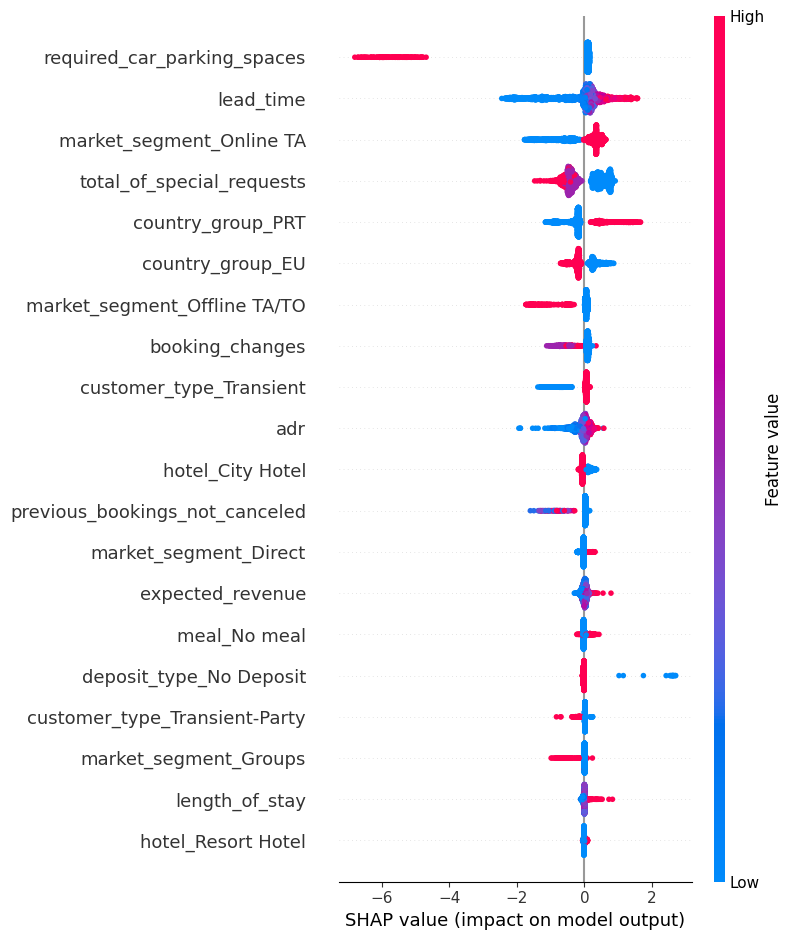

/tmp/ipykernel_1626313/2512378562.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(resort_shap_values, resort_X_shap, feature_names=feature_cols)


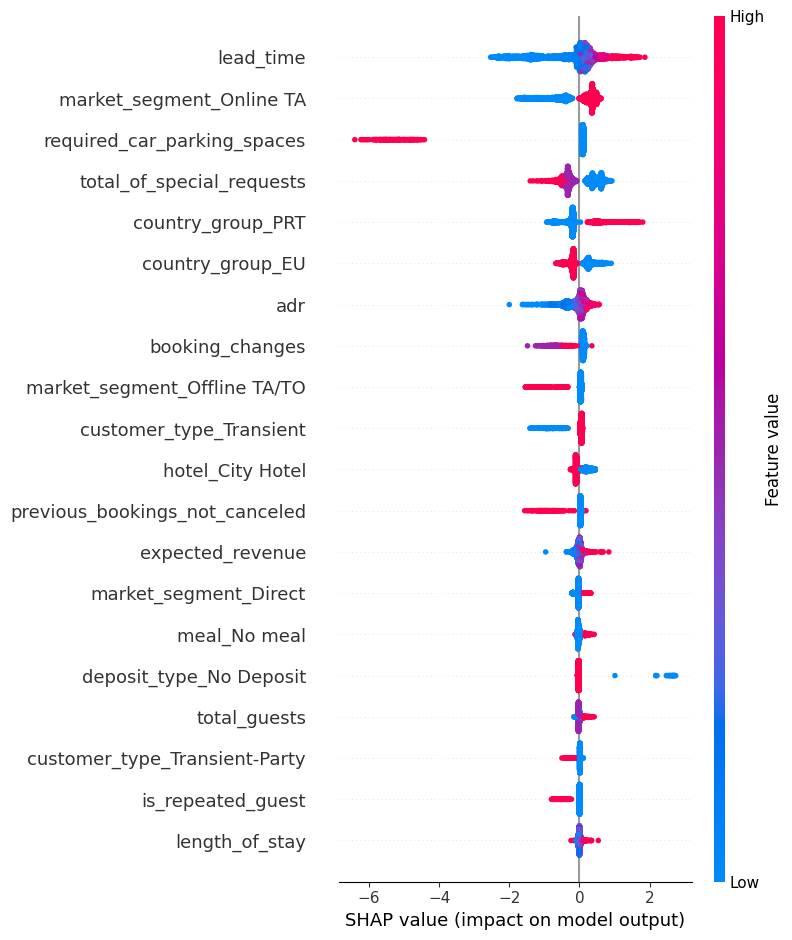

In [47]:
import shap
import pandas as pd
import numpy as np

def get_shap_global_summary(model, train_df, feature_cols, sample_size=2000):
    X_train = train_df[feature_cols].copy()

    if len(X_train) > sample_size:
        X_sample = X_train.sample(sample_size, random_state=42)
    else:
        X_sample = X_train.copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    shap_abs_mean = np.abs(shap_values).mean(axis=0)

    shap_summary_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": shap_abs_mean,
        "mean_feature_value": X_sample.mean(axis=0).values
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return explainer, X_sample, shap_values, shap_summary_df

city_explainer, city_X_shap, city_shap_values, city_shap_summary = get_shap_global_summary(
    city_fold_model, city_train, feature_cols, sample_size=2000
)

resort_explainer, resort_X_shap, resort_shap_values, resort_shap_summary = get_shap_global_summary(
    resort_fold_model, resort_train, feature_cols, sample_size=2000
)

display(city_shap_summary)
display(resort_shap_summary)

shap.summary_plot(city_shap_values, city_X_shap, feature_names=feature_cols)
shap.summary_plot(resort_shap_values, resort_X_shap, feature_names=feature_cols)

### LIME --> 1 sample에 대해서만 수행

In [48]:
from lime.lime_tabular import LimeTabularExplainer

def make_lime_explainer(train_df, feature_cols):
    X_train = np.asarray(train_df[feature_cols], dtype=np.float32)

    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_cols,
        class_names=["Not Canceled", "Canceled"],
        mode="classification",
        discretize_continuous=True,
        random_state=42
    )
    return explainer

city_lime_explainer = make_lime_explainer(city_train, feature_cols)
resort_lime_explainer = make_lime_explainer(resort_train, feature_cols)

city_fold_threshold = city_cv["fold_results_df"].loc[
    city_cv["fold_results_df"]["test_period"] == "2017-08", "threshold"
].iloc[0]

resort_fold_threshold = resort_cv["fold_results_df"].loc[
    resort_cv["fold_results_df"]["test_period"] == "2017-08", "threshold"
].iloc[0]

def add_prediction_to_test(model, test_h_df, feature_cols, threshold):
    X_test = np.asarray(test_h_df[feature_cols], dtype=np.float32)
    probs = model.predict_proba(X_test)[:, 1]

    out = test_h_df.copy()
    out["pred_prob"] = probs
    out["pred_label"] = (probs >= threshold).astype(int)
    out["threshold"] = threshold
    return out

city_test_scored = add_prediction_to_test(city_fold_model, city_test_h, feature_cols, city_fold_threshold)
resort_test_scored = add_prediction_to_test(resort_fold_model, resort_test_h, feature_cols, resort_fold_threshold)

In [49]:
def pick_lime_cases(scored_df):
    cases = {}

    # high risk & actual cancel
    tmp = scored_df[(scored_df["pred_label"] == 1) & (scored_df["is_canceled"] == 1)]
    if len(tmp) > 0:
        cases["high_risk_true_cancel"] = tmp.sort_values("pred_prob", ascending=False).index[0]

    # high risk & actual non-cancel
    tmp = scored_df[(scored_df["pred_label"] == 1) & (scored_df["is_canceled"] == 0)]
    if len(tmp) > 0:
        cases["high_risk_false_alarm"] = tmp.sort_values("pred_prob", ascending=False).index[0]

    # low risk & actual cancel
    tmp = scored_df[(scored_df["pred_label"] == 0) & (scored_df["is_canceled"] == 1)]
    if len(tmp) > 0:
        cases["missed_cancel"] = tmp.sort_values("pred_prob", ascending=True).index[0]

    # threshold 근처
    tmp = scored_df.copy()
    tmp["dist_to_threshold"] = np.abs(tmp["pred_prob"] - tmp["threshold"])
    if len(tmp) > 0:
        cases["borderline_case"] = tmp.sort_values("dist_to_threshold", ascending=True).index[0]

    return cases

city_cases = pick_lime_cases(city_test_scored)
resort_cases = pick_lime_cases(resort_test_scored)

city_cases, resort_cases

({'high_risk_true_cancel': np.int64(50884),
  'high_risk_false_alarm': np.int64(84248),
  'missed_cancel': np.int64(83814),
  'borderline_case': np.int64(50897)},
 {'high_risk_true_cancel': np.int64(10265),
  'high_risk_false_alarm': np.int64(32521),
  'missed_cancel': np.int64(9975),
  'borderline_case': np.int64(32624)})

In [53]:
def explain_one_with_lime(explainer, model, df_row, feature_cols, num_features=10):
    x = np.asarray(df_row[feature_cols], dtype=np.float32).reshape(1, -1)

    exp = explainer.explain_instance(
        data_row=x[0],
        predict_fn=model.predict_proba,
        num_features=num_features
    )

    lime_df = pd.DataFrame(exp.as_list(), columns=["feature_rule", "contribution"])
    return exp, lime_df

# City 예시
city_case_idx = city_cases["high_risk_true_cancel"]
city_case_row = city_test_scored.loc[[city_case_idx]]

city_lime_exp, city_lime_df = explain_one_with_lime(
    city_lime_explainer,
    city_fold_model,
    city_case_row,
    feature_cols,
    num_features=55
)

city_lime_df

,feature_rule,contribution
0,customer_type_Transient-Party <= 0.00,0.260633
1,country_group_PRT > 0.00,0.258728
2,required_car_parking_spaces <= 0.00,0.208452
3,previous_cancellations <= 0.00,-0.206417
4,lead_time > 137.00,0.200268
5,previous_bookings_not_canceled <= 0.00,0.182714
6,total_of_special_requests <= 0.00,0.169905
7,country_group_EU <= 0.00,0.146763
8,is_repeated_guest <= 0.00,0.121105
9,market_segment_Offline TA/TO <= 0.00,0.118628


In [56]:
# Resort 예시
resort_case_idx = resort_cases["high_risk_true_cancel"]
resort_case_row = resort_test_scored.loc[[resort_case_idx]]

resort_lime_exp, resort_lime_df = explain_one_with_lime(
    resort_lime_explainer,
    resort_fold_model,
    resort_case_row,
    feature_cols,
    num_features=55
)

resort_lime_df

,feature_rule,contribution
0,country_group_PRT > 0.00,0.288607
1,required_car_parking_spaces <= 0.00,0.254491
2,country_group_EU <= 0.00,0.182009
3,total_of_special_requests <= 0.00,0.181933
4,previous_bookings_not_canceled <= 0.00,0.160678
5,market_segment_Online TA <= 0.00,-0.128426
6,market_segment_Complementary <= 0.00,0.125785
7,customer_type_Transient-Party <= 0.00,0.122954
8,is_repeated_guest <= 0.00,0.121063
9,previous_cancellations <= 0.00,-0.087283


### Lime --> 각 samples에 따른 공통 패턴 추출 (opportunity 기반 LIME + rule)

In [63]:
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

def add_opportunity_score(scored_df, threshold_col="threshold"):
    df = scored_df.copy()

    if threshold_col not in df.columns:
        raise ValueError(f"{threshold_col} column not found")

    df["risk_excess"] = (df["pred_prob"] - df[threshold_col]).clip(lower=0)
    df["opportunity_score"] = df["risk_excess"] * df["expected_revenue"]

    # 참고용 우선순위 분류
    df["opportunity_tier"] = pd.qcut(
        df["opportunity_score"].rank(method="first"),
        q=4,
        labels=["Low", "Medium", "High", "Very High"]
    )

    return df

def select_opportunity_cases(
    scored_df,
    n_top=8,
    n_true_cancel=5,
    n_false_alarm=4,
    n_borderline_high_rev=3
):
    df = scored_df.copy()
    selected = []

    # 1) 전체 top opportunity
    top_all = df.sort_values("opportunity_score", ascending=False).head(n_top)
    selected.append(top_all)

    # 2) high opportunity & actual cancel
    part = df[df["is_canceled"] == 1].sort_values("opportunity_score", ascending=False).head(n_true_cancel)
    selected.append(part)

    # 3) high opportunity & actual non-cancel
    part = df[df["is_canceled"] == 0].sort_values("opportunity_score", ascending=False).head(n_false_alarm)
    selected.append(part)

    # 4) threshold 근처인데 revenue 큰 케이스
    tmp = df.copy()
    tmp["dist_to_threshold"] = np.abs(tmp["pred_prob"] - tmp["threshold"])
    part = tmp.sort_values(["dist_to_threshold", "expected_revenue"], ascending=[True, False]).head(n_borderline_high_rev)
    selected.append(part)

    out = pd.concat(selected, axis=0).drop_duplicates()
    return out.sort_values("opportunity_score", ascending=False)

def make_lime_explainer(train_df, feature_cols):
    X_train = np.asarray(train_df[feature_cols], dtype=np.float32)

    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_cols,
        class_names=["Not Canceled", "Canceled"],
        mode="classification",
        discretize_continuous=True,
        random_state=42
    )
    return explainer

def explain_many_with_lime(
    explainer,
    model,
    cases_df,
    feature_cols,
    num_features=12
):
    rows = []

    for idx in cases_df.index:
        row_df = cases_df.loc[[idx]]
        x = np.asarray(row_df[feature_cols], dtype=np.float32).reshape(1, -1)

        exp = explainer.explain_instance(
            data_row=x[0],
            predict_fn=model.predict_proba,
            num_features=num_features
        )

        lime_df = pd.DataFrame(exp.as_list(), columns=["feature_rule", "contribution"])
        lime_df["row_index"] = idx
        lime_df["pred_prob"] = float(row_df["pred_prob"].iloc[0])
        lime_df["pred_label"] = int(row_df["pred_label"].iloc[0])
        lime_df["actual_label"] = int(row_df["is_canceled"].iloc[0])
        lime_df["expected_revenue"] = float(row_df["expected_revenue"].iloc[0])
        lime_df["opportunity_score"] = float(row_df["opportunity_score"].iloc[0])

        rows.append(lime_df)

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "feature_rule", "contribution", "row_index",
            "pred_prob", "pred_label", "actual_label",
            "expected_revenue", "opportunity_score"
        ])

    return pd.concat(rows, ignore_index=True)

def summarize_opportunity_lime_rules(lime_many_df, min_case_count=2):
    if len(lime_many_df) == 0:
        return pd.DataFrame()

    summary = (
        lime_many_df.groupby("feature_rule", as_index=False)
        .agg(
            count=("row_index", "count"),
            case_count=("row_index", "nunique"),
            mean_contribution=("contribution", "mean"),
            abs_mean_contribution=("contribution", lambda s: np.mean(np.abs(s))),
            positive_ratio=("contribution", lambda s: np.mean(s > 0)),
            negative_ratio=("contribution", lambda s: np.mean(s < 0)),
            mean_opportunity=("opportunity_score", "mean"),
            sum_opportunity=("opportunity_score", "sum"),
        )
        .sort_values(
            ["case_count", "sum_opportunity", "abs_mean_contribution"],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    summary = summary[summary["case_count"] >= min_case_count].copy()
    return summary

def make_opportunity_rule_candidates(
    rule_summary_df,
    min_case_count=3,
    min_abs_contribution=0.05
):
    if len(rule_summary_df) == 0:
        return pd.DataFrame()

    out = rule_summary_df.copy()
    out = out[
        (out["case_count"] >= min_case_count) &
        (out["abs_mean_contribution"] >= min_abs_contribution)
    ].copy()

    def classify_rule(row):
        # contribution이 양수면 취소확률 상승 방향
        # 그리고 opportunity가 높으면 "개입 타겟"
        if row["mean_contribution"] > 0:
            return "Target for Intervention"
        elif row["mean_contribution"] < 0:
            return "Stable / Low Priority"
        return "Neutral"

    out["rule_type"] = out.apply(classify_rule, axis=1)

    return out[[
        "rule_type",
        "feature_rule",
        "case_count",
        "mean_contribution",
        "abs_mean_contribution",
        "mean_opportunity",
        "sum_opportunity",
        "positive_ratio",
        "negative_ratio"
    ]].sort_values(
        ["rule_type", "sum_opportunity", "case_count", "abs_mean_contribution"],
        ascending=[True, False, False, False]
    ).reset_index(drop=True)
    
def make_practical_opportunity_report(rule_candidates_df, top_n=15):
    if len(rule_candidates_df) == 0:
        return pd.DataFrame()

    out = rule_candidates_df.head(top_n).copy()

    def action_hint(rule_type):
        if rule_type == "Target for Intervention":
            return "재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링"
        elif rule_type == "Stable / Low Priority":
            return "과도한 개입 자제 / 일반 운영 / 업셀 중심"
        return "추가 검토"

    out["recommended_action"] = out["rule_type"].map(action_hint)
    return out

In [67]:
city_test_scored_op = add_opportunity_score(city_test_scored, threshold_col="threshold")

city_opportunity_cases = select_opportunity_cases(
    city_test_scored_op,
    n_top=8,
    n_true_cancel=5,
    n_false_alarm=4,
    n_borderline_high_rev=3
)

city_lime_explainer = make_lime_explainer(city_train, feature_cols)

city_lime_op_df = explain_many_with_lime(
    explainer=city_lime_explainer,
    model=city_fold_model,
    cases_df=city_opportunity_cases,
    feature_cols=feature_cols,
    num_features=12
)

city_op_rule_summary = summarize_opportunity_lime_rules(
    city_lime_op_df,
    min_case_count=2
)

city_op_rule_candidates = make_opportunity_rule_candidates(
    city_op_rule_summary,
    min_case_count=3,
    min_abs_contribution=0.05
)

city_practical_op_report = make_practical_opportunity_report(
    city_op_rule_candidates,
    top_n=30
)

city_opportunity_cases[[
    "pred_prob", "threshold", "pred_label", "is_canceled",
    "expected_revenue", "opportunity_score", "opportunity_tier"
]]

city_practical_op_report

,rule_type,feature_rule,case_count,mean_contribution,abs_mean_contribution,mean_opportunity,sum_opportunity,positive_ratio,negative_ratio,recommended_action
0,Stable / Low Priority,country_group_PRT <= 0.00,14,-0.250115,0.250115,953.985413,13355.795776,0.0,1.0,과도한 개입 자제 / 일반 운영 / 업셀 중심
1,Stable / Low Priority,previous_cancellations <= 0.00,14,-0.191292,0.191292,951.704306,13323.860279,0.0,1.0,과도한 개입 자제 / 일반 운영 / 업셀 중심
2,Stable / Low Priority,0.00 < country_group_EU <= 1.00,10,-0.145204,0.145204,779.549321,7795.493212,0.0,1.0,과도한 개입 자제 / 일반 운영 / 업셀 중심
3,Stable / Low Priority,deposit_type_Refundable <= 0.00,5,-0.055001,0.108627,693.829565,3469.147827,0.4,0.6,과도한 개입 자제 / 일반 운영 / 업셀 중심
4,Stable / Low Priority,0.00 < total_of_special_requests <= 1.00,3,-0.121156,0.121156,887.523108,2662.569325,0.0,1.0,과도한 개입 자제 / 일반 운영 / 업셀 중심
5,Target for Intervention,customer_type_Transient-Party <= 0.00,15,0.261024,0.261024,965.326239,14479.893583,1.0,0.0,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
6,Target for Intervention,required_car_parking_spaces <= 0.00,15,0.218353,0.218353,965.326239,14479.893583,1.0,0.0,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
7,Target for Intervention,previous_bookings_not_canceled <= 0.00,15,0.173275,0.173275,965.326239,14479.893583,1.0,0.0,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
8,Target for Intervention,market_segment_Offline TA/TO <= 0.00,15,0.128252,0.128252,965.326239,14479.893583,1.0,0.0,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
9,Target for Intervention,is_repeated_guest <= 0.00,14,0.113437,0.113437,970.755239,13590.573349,1.0,0.0,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링


In [ ]:
resort_test_scored_op = add_opportunity_score(resort_test_scored, threshold_col="threshold")

resort_opportunity_cases = select_opportunity_cases(
    resort_test_scored_op,
    n_top=8,
    n_true_cancel=5,
    n_false_alarm=4,
    n_borderline_high_rev=3
)

resort_lime_explainer = make_lime_explainer(resort_train, feature_cols)

resort_lime_op_df = explain_many_with_lime(
    explainer=resort_lime_explainer,
    model=resort_fold_model,
    cases_df=resort_opportunity_cases,
    feature_cols=feature_cols,
    num_features=12
)

resort_op_rule_summary = summarize_opportunity_lime_rules(
    resort_lime_op_df,
    min_case_count=2
)

resort_op_rule_candidates = make_opportunity_rule_candidates(
    resort_op_rule_summary,
    min_case_count=3,
    min_abs_contribution=0.05
)

resort_practical_op_report = make_practical_opportunity_report(
    resort_op_rule_candidates,
    top_n=30
)

resort_opportunity_cases[[
    "pred_prob", "threshold", "pred_label", "is_canceled",
    "expected_revenue", "opportunity_score", "opportunity_tier"
]]

resort_practical_op_report

,rule_type,feature_rule,case_count,mean_contribution,abs_mean_contribution,mean_opportunity,sum_opportunity,positive_ratio,negative_ratio,recommended_action
0,Stable / Low Priority,previous_cancellations <= 0.00,13,-0.140771,0.140771,1806.818900,23488.645706,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
1,Stable / Low Priority,country_group_PRT <= 0.00,7,-0.283189,0.283189,1321.553310,9250.873173,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
2,Stable / Low Priority,0.00 < country_group_EU <= 1.00,5,-0.176610,0.176610,1568.016498,7840.082491,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
3,Stable / Low Priority,deposit_type_Refundable <= 0.00,3,-0.025258,0.073700,2282.151185,6846.453554,0.333333,0.666667,과도한 개입 자제 / 일반 운영 / 업셀 중심
4,Stable / Low Priority,0.00 < total_of_special_requests <= 1.00,3,-0.126916,0.126916,1380.428653,4141.285958,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
5,Stable / Low Priority,deposit_type_Non Refund <= 0.00,3,-0.100641,0.100641,1137.025910,3411.077729,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
6,Stable / Low Priority,total_of_special_requests > 1.00,3,-0.112236,0.112236,1112.277291,3336.831872,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
7,Stable / Low Priority,booking_changes > 0.00,3,-0.095388,0.095388,0.808089,2.424268,0.000000,1.000000,과도한 개입 자제 / 일반 운영 / 업셀 중심
8,Target for Intervention,required_car_parking_spaces <= 0.00,15,0.240669,0.240669,1788.108513,26821.627688,1.000000,0.000000,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
9,Target for Intervention,previous_bookings_not_canceled <= 0.00,15,0.157178,0.157178,1788.108513,26821.627688,1.000000,0.000000,재확인 메시지 / 선결제 유도 / 혜택 제안 / 수동 모니터링
